# SKAW Similarities 
- Complete Agreements, Partial Agreements, and Complete Disagreements of the Human Coder and LightCast

In [20]:
# Imports
import ast
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repair_excel_corrupted_soc(value):
    """Recover SOC codes that Excel has coerced into date-like values."""
    if pd.isna(value):
        return np.nan

    if hasattr(value, "year") and hasattr(value, "month") and hasattr(value, "day"):
        year = f"{int(value.year):04d}"
        month = f"{int(value.month):02d}"
        return f"{year[:2]}-{year[2:]}{month}"

    text = str(value).strip()
    if not text:
        return np.nan

    soc_match = re.search(r"(\d{2})-(\d{4})(?:\.\d+)?", text)
    if soc_match:
        return f"{soc_match.group(1)}-{soc_match.group(2)}"

    datetime_match = re.match(r"^(\d{4})-(\d{2})-(\d{2})(?:\s+.*)?$", text)
    if datetime_match:
        year, month, _day = datetime_match.groups()
        return f"{year[:2]}-{year[2:]}{month}"

    digits = re.sub(r"\D", "", text)
    if len(digits) >= 6:
        digits = digits[:6]
        return f"{digits[:2]}-{digits[2:6]}"

    return text

In [21]:
# Dataframe imports
excel_path = r"C:\Users\linds\OneDrive\Documents\CII2 Multi-site\1058 rows graded Final.xlsx"
similarity_path = r"C:\Users\linds\OneDrive\Documents\CII2 Multi-site\merged_similarity_scores_updated_04132026.csv"

df_coded = pd.read_excel(
    excel_path,
    converters={
        "SOC_5": repair_excel_corrupted_soc,
        "ONET_2019": repair_excel_corrupted_soc,
    }
)

if "df_sim_metrics" not in globals():
    df_sim_metrics = pd.read_csv(similarity_path)

onet_is_standard = df_coded["ONET_2019"].astype("string").str.fullmatch(r"\d{2}-\d{4}", na=False)
print("Rows with non-standard ONET_2019 after import:", int((~onet_is_standard & df_coded["ONET_2019"].notna()).sum()))

Rows with non-standard ONET_2019 after import: 0


- Clean data frames 
- Plot descriptive figures

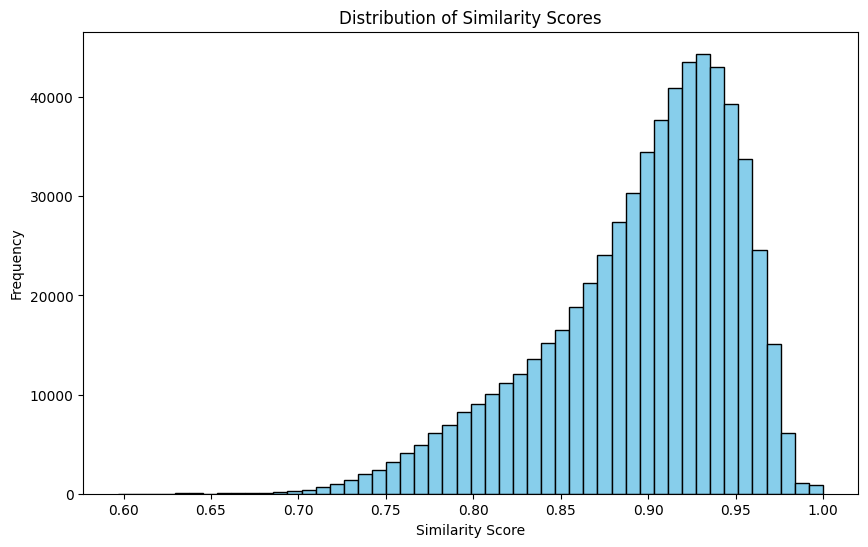

In [22]:
plt.figure(figsize=(10,6))
plt.hist(df_sim_metrics['original_cosine_SKAWS_value'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.show()

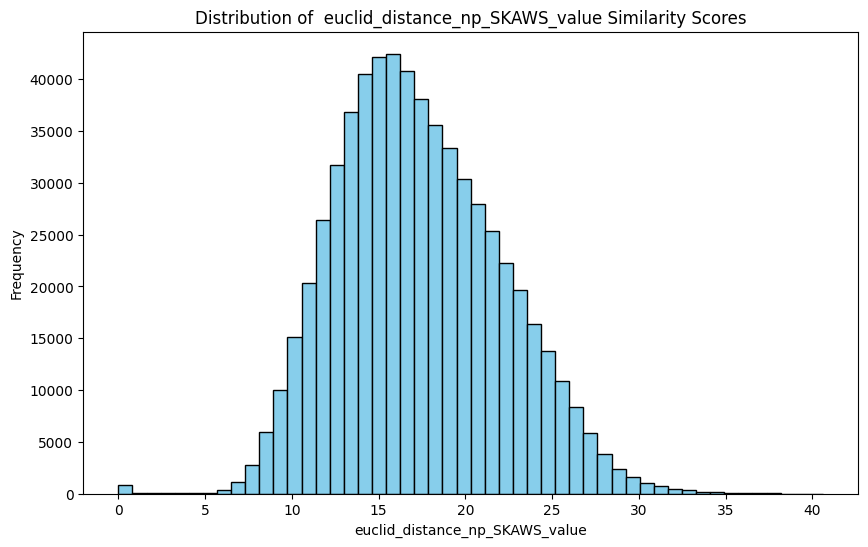

In [23]:
plt.figure(figsize=(10,6))
plt.hist(df_sim_metrics['Euclid_distance_np_SKAWS_value'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of  euclid_distance_np_SKAWS_value Similarity Scores')
plt.xlabel('euclid_distance_np_SKAWS_value')
plt.ylabel('Frequency')
plt.show()

In [24]:
completely_disagree_df=df_coded[df_coded['map verdict 5-digit']=='Completely disagree']
completely_agree_df=df_coded[df_coded['map verdict 5-digit']=='Completely agree']
partially_agree_df=df_coded[df_coded['map verdict 5-digit']=='Partially agree']


## Completely Disagree
Build pair-level similarity table:
- Extracts and normalizes human SOC codes from `Human options 6-digit`
- Normalizes Lightcast SOC from `ONET_2019`
- Creates one row per `(ONET_2019, human SOC)` pair
- Joins to `df_sim_metrics` to pull `cosine_SKAWS_value`

In [25]:
def normalize_soc(code):
    """Normalize SOC codes to 6-digit format NN-NNNN."""
    cleaned = repair_excel_corrupted_soc(code)
    if pd.isna(cleaned):
        return np.nan

    text = str(cleaned).strip()
    soc_match = re.search(r"(\d{2})-(\d{4})", text)
    if soc_match:
        return f"{soc_match.group(1)}-{soc_match.group(2)}"

    digits = re.sub(r"\D", "", text)
    if len(digits) < 6:
        return np.nan

    digits = digits[:6]
    return f"{digits[:2]}-{digits[2:6]}"


def extract_human_soc_list(cell):
    """
    Extract SOC codes from dict-like strings such as:
    {'15-1211.00': 'Computer Systems Analysts', ...}
    """
    if pd.isna(cell):
        return []

    s = str(cell).strip()
    if not s:
        return []

    codes = []

    try:
        obj = ast.literal_eval(s)
        if isinstance(obj, dict):
            codes = list(obj.keys())
        elif isinstance(obj, (list, tuple)):
            codes = list(obj)
        else:
            codes = re.findall(r"\d{2}-\d{4}(?:\.\d+)?", s)
    except Exception:
        codes = re.findall(r"\d{2}-\d{4}(?:\.\d+)?", s)

    codes = [normalize_soc(c) for c in codes]
    codes = [c for c in codes if pd.notna(c)]

    seen = set()
    out = []
    for c in codes:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out


def dedupe_unordered_pairs(df, left_col, right_col, value_col="original_cosine_SKAWS_value"):
    """Keep one record per unordered SOC pair (A-B equals B-A), using max similarity."""
    d = df.copy()
    d[["_soc_low", "_soc_high"]] = d.apply(
        lambda r: pd.Series(sorted([str(r[left_col]), str(r[right_col])])),
        axis=1
    )
    d = d.sort_values(value_col, ascending=False, na_position="last")
    d = d.drop_duplicates(subset=["_soc_low", "_soc_high"], keep="first")
    d[left_col] = d["_soc_low"]
    d[right_col] = d["_soc_high"]
    return d.drop(columns=["_soc_low", "_soc_high"])


# 1) Prepare disagreement rows and explode human SOC selections
work = completely_disagree_df.copy()
work["ONET_2019_norm"] = work["ONET_2019"].apply(normalize_soc)
work["human_soc_list"] = work["Human options 6-digit"].apply(extract_human_soc_list)

pairs = (
    work
    .explode("human_soc_list")
    .rename(columns={"human_soc_list": "human_soc"})
)

pairs = pairs[pairs["ONET_2019_norm"].notna() & pairs["human_soc"].notna()].copy()


# 2) Prepare similarity lookup table from df_sim_metrics
sim = df_sim_metrics.copy()
sim["origin_soc_norm"] = sim["origin_soc"].apply(normalize_soc)
sim["destination_soc_norm"] = sim["destination_soc"].apply(normalize_soc)

sim = sim[["origin_soc_norm", "destination_soc_norm", "original_cosine_SKAWS_value"]].dropna(
    subset=["origin_soc_norm", "destination_soc_norm"]
)


# 3) Merge both directions and keep whichever match exists
m1 = pairs.merge(
    sim,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["origin_soc_norm", "destination_soc_norm"],
    how="left"
).rename(columns={"original_cosine_SKAWS_value": "cosine_A"})

m2 = pairs.merge(
    sim,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["destination_soc_norm", "origin_soc_norm"],
    how="left"
).rename(columns={"original_cosine_SKAWS_value": "cosine_B"})

result = m1.copy()
result["original_cosine_SKAWS_value"] = result["cosine_A"].combine_first(m2["cosine_B"])

result["match_direction"] = np.where(
    result["cosine_A"].notna(),
    "A: ONET_2019->human",
    np.where(m2["cosine_B"].notna(), "B: human->ONET_2019", "no_match")
)


# 4) Final pair-level output for plotting/analysis
final_pairs = result[[
    "ONET_2019",
    "ONET_2019_norm",
    "human_soc",
    "original_cosine_SKAWS_value",
    "match_direction"
]].copy()

print("Rows in pair-level output:", len(final_pairs))
print("Pairs with similarity found:", final_pairs["original_cosine_SKAWS_value"].notna().sum())
final_pairs.head(20)

Rows in pair-level output: 498
Pairs with similarity found: 382


,ONET_2019,ONET_2019_norm,human_soc,original_cosine_SKAWS_value,match_direction
0,11-9111,11-9111,21-1013,0.920778,A: ONET_2019->human
1,11-9111,11-9111,21-1014,NaN,no_match
2,11-9111,11-9111,21-1019,0.956836,A: ONET_2019->human
3,11-2021,11-2021,13-2054,0.973454,A: ONET_2019->human
4,11-2021,11-2021,13-1161,0.979223,A: ONET_2019->human
5,11-2021,11-2021,15-2031,0.954574,A: ONET_2019->human
6,11-2021,11-2021,15-2051,0.964180,A: ONET_2019->human
7,11-9111,11-9111,29-2099,0.956199,A: ONET_2019->human
8,11-2021,11-2021,19-1021,0.896084,A: ONET_2019->human
9,11-2021,11-2021,11-9121,0.944172,A: ONET_2019->human


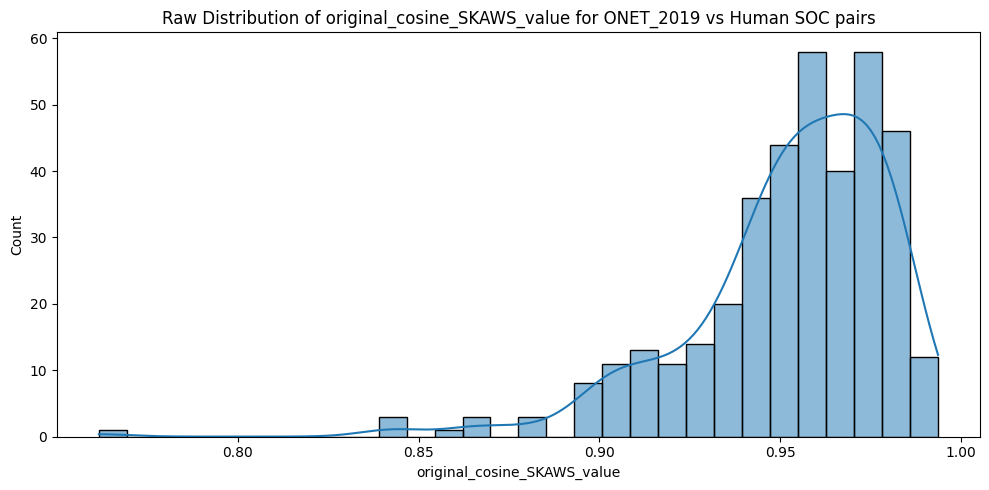

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = final_pairs[final_pairs["original_cosine_SKAWS_value"].notna()].copy()

plt.figure(figsize=(10, 5))
sns.histplot(plot_df["original_cosine_SKAWS_value"], bins=30, kde=True)
plt.title("Raw Distribution of original_cosine_SKAWS_value for ONET_2019 vs Human SOC pairs")
plt.xlabel("original_cosine_SKAWS_value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

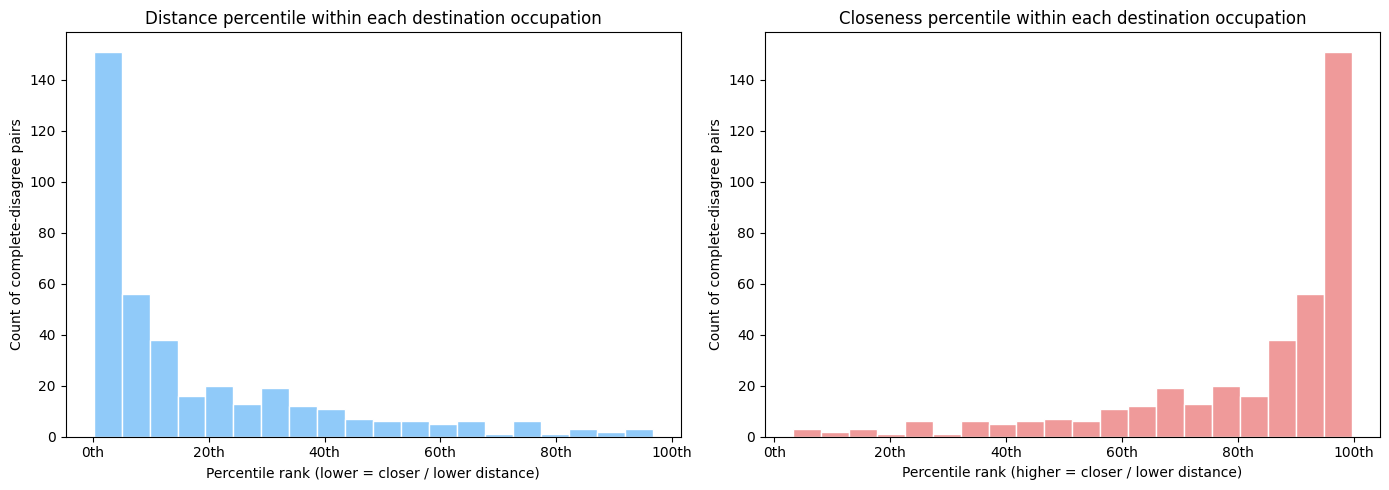

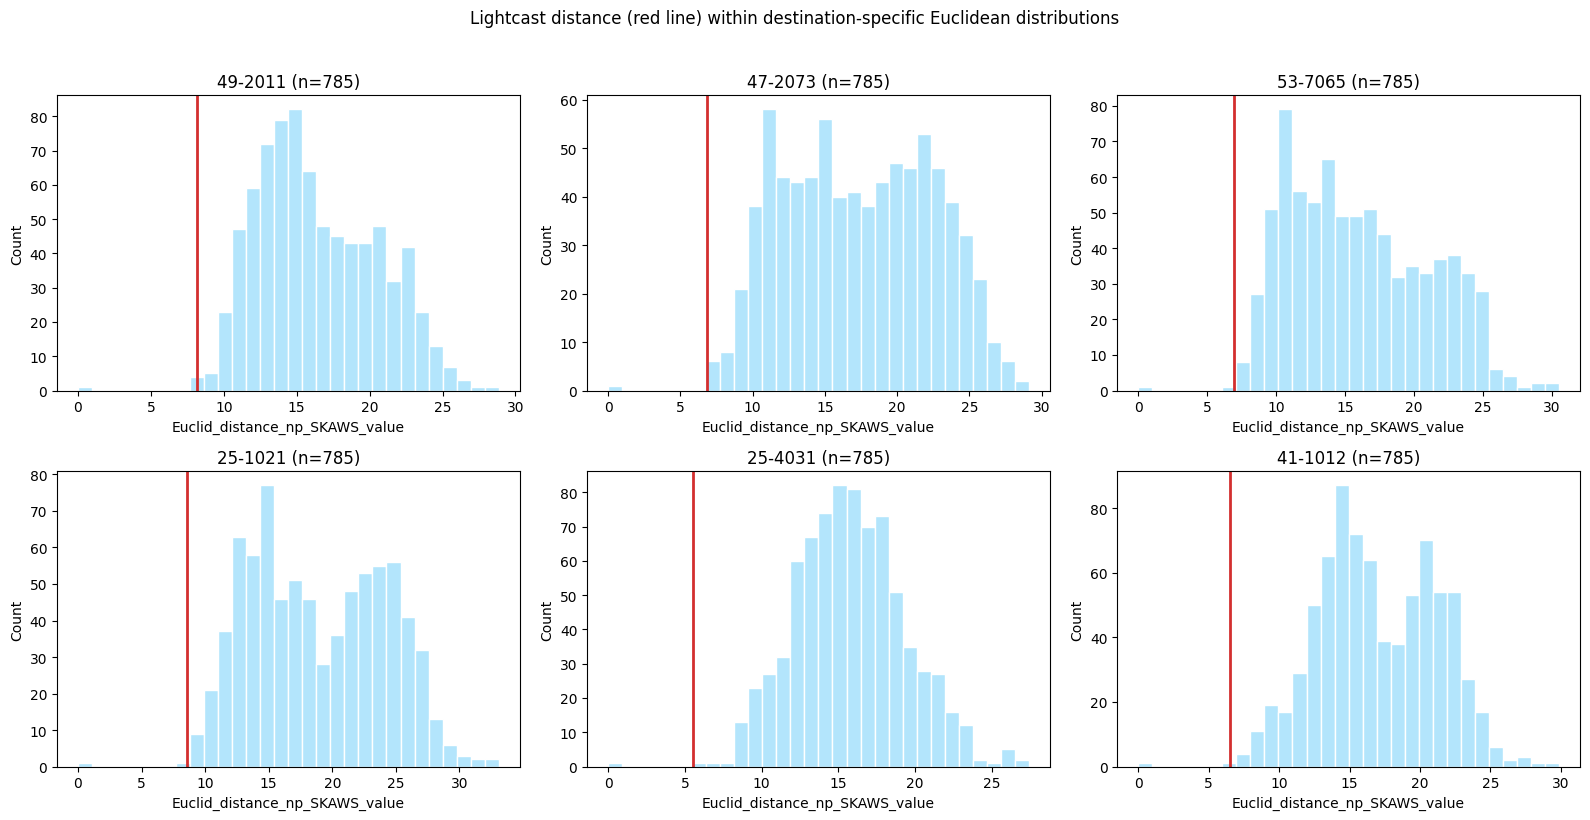

Destination-specific closeness percentile summary (n=382):
count    382.0
mean      82.6
std       21.3
min        3.2
25%       73.2
50%       92.2
75%       98.0
max       99.7
Name: closeness_percentile_rank, dtype: float64

Destination-specific distance percentile summary (n=382):
count    382.0
mean      17.3
std       21.3
min        0.1
25%        1.9
50%        7.6
75%       26.7
max       96.7
Name: distance_percentile_rank, dtype: float64

Rows without Euclidean match:
116


,ONET_2019_norm,human_soc,match_direction,destination_occ,destination_distribution_n,Euclid_distance_np_SKAWS_value,distance_percentile_rank,closeness_percentile_rank
0,11-9111,21-1013,A: ONET_2019->human,21-1013,785,17.136125,30.318471,69.554140
2,11-9111,21-1019,A: ONET_2019->human,21-1019,785,13.065796,21.528662,78.343949
3,11-2021,13-2054,A: ONET_2019->human,13-2054,785,10.330256,5.605096,94.267516
4,11-2021,13-1161,A: ONET_2019->human,13-1161,785,8.783747,1.273885,98.598726
5,11-2021,15-2031,A: ONET_2019->human,15-2031,785,12.791454,6.114650,93.757962
6,11-2021,15-2051,A: ONET_2019->human,15-2051,785,11.432559,7.770701,92.101911
7,11-9111,29-2099,A: ONET_2019->human,29-2099,785,14.398972,54.904459,44.968153
8,11-2021,19-1021,A: ONET_2019->human,19-1021,785,19.861648,29.554140,70.318471
9,11-2021,11-9121,A: ONET_2019->human,11-9121,785,13.272545,12.356688,87.515924
10,11-2021,17-2031,A: ONET_2019->human,17-2031,785,18.258011,21.656051,78.216561


In [27]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Percentile analysis — Completely Disagree
# Destination-specific reference: for each human-coded destination occupation,
# use the distribution of Euclidean distances from ALL origins mapping to that destination in df_sim_metrics.
# Then locate the Lightcast-vs-human distance within that destination-specific distribution.

metric_col = "Euclid_distance_np_SKAWS_value"

# Build pair-level Euclidean metric for complete-disagree ONET_2019 vs human_soc pairs
disagree_df = final_pairs.copy()
pairs_for_metric = final_pairs[["ONET_2019_norm", "human_soc"]].copy()

sim_metric = df_sim_metrics[["origin_soc", "destination_soc", metric_col]].copy()
sim_metric["origin_soc_norm"] = sim_metric["origin_soc"].apply(normalize_soc)
sim_metric["destination_soc_norm"] = sim_metric["destination_soc"].apply(normalize_soc)
sim_metric = sim_metric.dropna(subset=["origin_soc_norm", "destination_soc_norm", metric_col]).copy()

metric_m1 = pairs_for_metric.merge(
    sim_metric,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["origin_soc_norm", "destination_soc_norm"],
    how="left",
).rename(columns={metric_col: "euclid_A"})

metric_m2 = pairs_for_metric.merge(
    sim_metric,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["destination_soc_norm", "origin_soc_norm"],
    how="left",
).rename(columns={metric_col: "euclid_B"})

disagree_df[metric_col] = metric_m1["euclid_A"].combine_first(metric_m2["euclid_B"])
disagree_df = disagree_df[disagree_df[metric_col].notna()].copy()

# Human-coded SOC is the destination occupation for this analysis.
disagree_df["destination_occ"] = disagree_df["human_soc"]

# Build destination-specific Euclidean distributions from full df_sim_metrics.
all_dest_dist = df_sim_metrics[["destination_soc", metric_col]].copy()
all_dest_dist["destination_norm"] = all_dest_dist["destination_soc"].apply(normalize_soc)
all_dest_dist = all_dest_dist.dropna(subset=["destination_norm", metric_col]).copy()

dest_to_vals = {
    d: g[metric_col].to_numpy()
    for d, g in all_dest_dist.groupby("destination_norm", sort=False)
}
dest_counts = all_dest_dist.groupby("destination_norm")[metric_col].size()

def destination_distance_percentile(row):
    dest = row["destination_occ"]
    val = row[metric_col]
    arr = dest_to_vals.get(dest)
    if pd.isna(dest) or pd.isna(val) or arr is None or len(arr) == 0:
        return np.nan
    return float((arr < val).mean() * 100)

def destination_closeness_percentile(row):
    dest = row["destination_occ"]
    val = row[metric_col]
    arr = dest_to_vals.get(dest)
    if pd.isna(dest) or pd.isna(val) or arr is None or len(arr) == 0:
        return np.nan
    return float((arr > val).mean() * 100)

disagree_df["distance_percentile_rank"] = disagree_df.apply(destination_distance_percentile, axis=1)
disagree_df["closeness_percentile_rank"] = disagree_df.apply(destination_closeness_percentile, axis=1)
disagree_df["destination_distribution_n"] = disagree_df["destination_occ"].map(dest_counts)

valid_close = disagree_df["closeness_percentile_rank"].dropna()

# Figure 1: destination-specific percentile summaries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(disagree_df["distance_percentile_rank"].dropna(), bins=20, color="#90CAF9", edgecolor="white")
ax.set_title("Distance percentile within each destination occupation")
ax.set_xlabel("Percentile rank (lower = closer / lower distance)")
ax.set_ylabel("Count of complete-disagree pairs")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}th"))

ax2 = axes[1]
ax2.hist(valid_close, bins=20, color="#EF9A9A", edgecolor="white")
ax2.set_title("Closeness percentile within each destination occupation")
ax2.set_xlabel("Percentile rank (higher = closer / lower distance)")
ax2.set_ylabel("Count of complete-disagree pairs")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}th"))

plt.tight_layout()
plt.show()

# Figure 2: sample destination-specific distributions with Lightcast value marked
sample_n = 6
sample = disagree_df[["destination_occ", metric_col, "closeness_percentile_rank"]].dropna().copy()
sample = sample.sort_values("closeness_percentile_rank", ascending=False).head(sample_n)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=False, sharey=False)
axes = axes.flatten()

for i, (_, r) in enumerate(sample.iterrows()):
    dest = r["destination_occ"]
    val = r[metric_col]
    arr = dest_to_vals.get(dest, np.array([]))

    ax = axes[i]
    if len(arr) > 0:
        ax.hist(arr, bins=30, color="#B3E5FC", edgecolor="white")
        ax.axvline(val, color="#D32F2F", linewidth=2)
        ax.set_title(f"{dest} (n={len(arr)})")
        ax.set_xlabel(metric_col)
        ax.set_ylabel("Count")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Lightcast distance (red line) within destination-specific Euclidean distributions", y=1.02)
plt.tight_layout()
plt.show()

print(f"Destination-specific closeness percentile summary (n={len(valid_close)}):")
print(disagree_df["closeness_percentile_rank"].describe().round(1))

print("\nDestination-specific distance percentile summary (n={}):".format(len(disagree_df)))
print(disagree_df["distance_percentile_rank"].describe().round(1))

print("\nRows without Euclidean match:")
print(int(final_pairs.shape[0] - disagree_df.shape[0]))

display(
    disagree_df[[
        "ONET_2019_norm",
        "human_soc",
        "match_direction",
        "destination_occ",
        "destination_distribution_n",
        metric_col,
        "distance_percentile_rank",
        "closeness_percentile_rank",
    ]].head(20)
)


In [28]:
# Example pairs with 99th percentile values
overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
p99 = np.percentile(overall, 99)
print(f"99th percentile threshold (overall): {p99:.4f}")

top_pairs = final_pairs[final_pairs["original_cosine_SKAWS_value"] >= p99][["ONET_2019", "human_soc", "original_cosine_SKAWS_value"]]
top_pairs = dedupe_unordered_pairs(top_pairs, "ONET_2019", "human_soc", "original_cosine_SKAWS_value")
top_pairs = top_pairs.sort_values("original_cosine_SKAWS_value", ascending=False)

print(f"\nDisagree pairs at or above 99th percentile (unique unordered pairs, n={len(top_pairs)}):")
display(top_pairs)

99th percentile threshold (overall): 0.9775

Disagree pairs at or above 99th percentile (unique unordered pairs, n=48):


,ONET_2019,human_soc,original_cosine_SKAWS_value
126,17-2111,19-5011,0.993581
11,11-2011,11-2021,0.989804
76,15-1243,15-1252,0.988877
140,21-1019,21-1021,0.987882
168,13-1151,25-9031,0.987470
329,41-1012,43-1011,0.987391
143,21-1021,21-1099,0.987027
64,15-1252,15-1299,0.986554
90,17-2141,17-2199,0.986346
92,17-2061,17-2071,0.985897


## Completely Agree
Build pair-level similarity table:
- Extracts and normalizes human SOC codes from `Human options 6-digit`
- Normalizes Lightcast SOC from `ONET_2019`
- Creates one row per `(ONET_2019, human SOC)` pair
- Joins to `df_sim_metrics` to pull `cosine_SKAWS_value`

In [29]:
# Build pair-level similarity table for completely_agree_df
agree_work = completely_agree_df.copy()
agree_work["ONET_2019_norm"] = agree_work["ONET_2019"].apply(normalize_soc)
agree_work["human_soc_list"] = agree_work["Human options 6-digit"].apply(extract_human_soc_list)

agree_pairs = (
    agree_work
    .explode("human_soc_list")
    .rename(columns={"human_soc_list": "human_soc"})
)
agree_pairs = agree_pairs[
    agree_pairs["ONET_2019_norm"].notna() & agree_pairs["human_soc"].notna()
].copy()

agree_m1 = agree_pairs.merge(
    sim,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["origin_soc_norm", "destination_soc_norm"],
    how="left"
).rename(columns={"original_cosine_SKAWS_value": "cosine_A"})

agree_m2 = agree_pairs.merge(
    sim,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["destination_soc_norm", "origin_soc_norm"],
    how="left"
).rename(columns={"original_cosine_SKAWS_value": "cosine_B"})

agree_result = agree_m1.copy()
agree_result["original_cosine_SKAWS_value"] = agree_result["cosine_A"].combine_first(agree_m2["cosine_B"])
agree_result["match_direction"] = np.where(
    agree_result["cosine_A"].notna(), "A: ONET_2019->human",
    np.where(agree_m2["cosine_B"].notna(), "B: human->ONET_2019", "no_match")
)

agree_final_pairs = agree_result[[
    "ONET_2019", "ONET_2019_norm", "human_soc", "original_cosine_SKAWS_value", "match_direction"
]].copy()

print("Rows in pair-level output:", len(agree_final_pairs))
print("Pairs with similarity found:", agree_final_pairs["original_cosine_SKAWS_value"].notna().sum())
agree_final_pairs.head(10)

Rows in pair-level output: 542
Pairs with similarity found: 477


,ONET_2019,ONET_2019_norm,human_soc,original_cosine_SKAWS_value,match_direction
0,11-9051,11-9051,11-9051,1.0,A: ONET_2019->human
1,11-3031,11-3031,11-3031,1.0,A: ONET_2019->human
2,11-9051,11-9051,11-9051,1.0,A: ONET_2019->human
3,11-9051,11-9051,11-9051,1.0,A: ONET_2019->human
4,11-3031,11-3031,11-3031,1.0,A: ONET_2019->human
5,11-3121,11-3121,11-3121,1.0,A: ONET_2019->human
6,11-2032,11-2032,11-2032,NaN,no_match
7,11-3021,11-3021,11-3021,1.0,A: ONET_2019->human
8,11-1021,11-1021,11-1021,1.0,A: ONET_2019->human
9,11-3013,11-3013,11-3013,1.0,A: ONET_2019->human


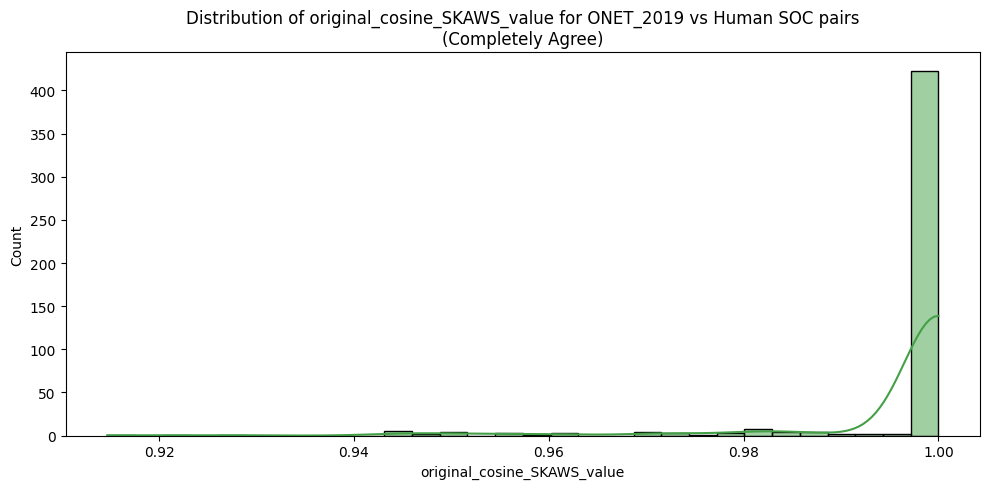

In [30]:
# Distribution of similarity scores — Completely Agree
agree_plot_df = agree_final_pairs[agree_final_pairs["original_cosine_SKAWS_value"].notna()].copy()

plt.figure(figsize=(10, 5))
sns.histplot(agree_plot_df["original_cosine_SKAWS_value"], bins=30, kde=True, color="#43A047")
plt.title("Distribution of original_cosine_SKAWS_value for ONET_2019 vs Human SOC pairs\n(Completely Agree)")
plt.xlabel("original_cosine_SKAWS_value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

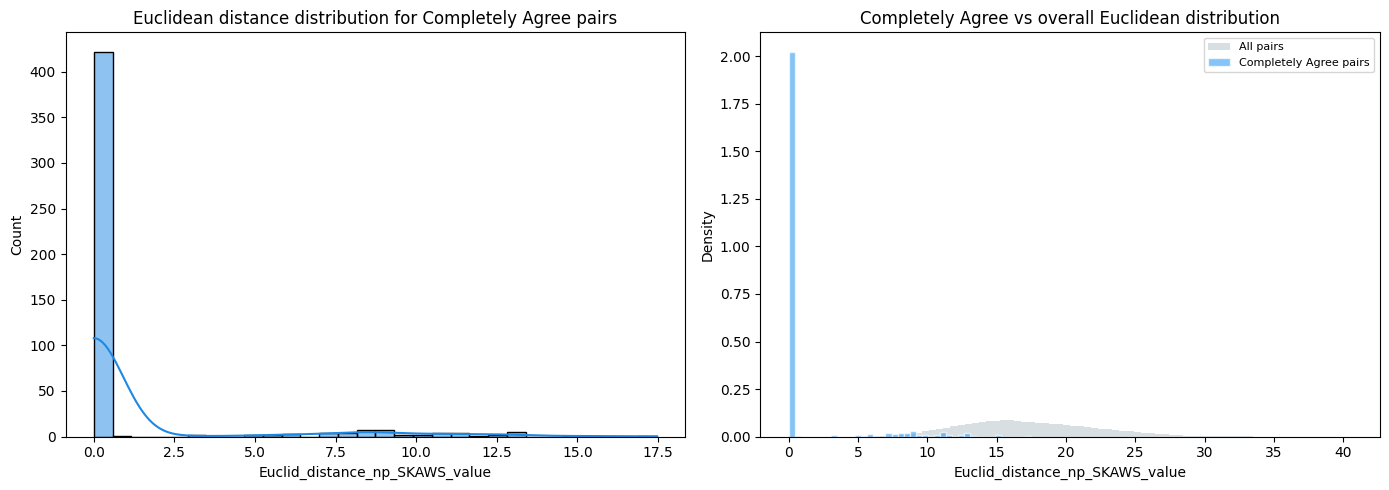

Completely Agree rows with Euclidean distance: 477
count    477.000
mean       1.060
std        3.126
min        0.000
25%        0.000
50%        0.000
75%        0.000
max       17.477
Name: Euclid_distance_np_SKAWS_value, dtype: float64


In [31]:
# Distribution of Euclidean distances — Completely Agree
metric_col = "Euclid_distance_np_SKAWS_value"

# Pull Euclidean distance for each ONET_2019 <-> human_soc pair (both possible directions)
agree_pairs_for_metric = agree_final_pairs[["ONET_2019_norm", "human_soc"]].copy()

agree_sim_metric = df_sim_metrics[["origin_soc", "destination_soc", metric_col]].copy()
agree_sim_metric["origin_soc_norm"] = agree_sim_metric["origin_soc"].apply(normalize_soc)
agree_sim_metric["destination_soc_norm"] = agree_sim_metric["destination_soc"].apply(normalize_soc)
agree_sim_metric = agree_sim_metric.dropna(subset=["origin_soc_norm", "destination_soc_norm", metric_col]).copy()

agree_metric_m1 = agree_pairs_for_metric.merge(
    agree_sim_metric,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["origin_soc_norm", "destination_soc_norm"],
    how="left",
).rename(columns={metric_col: "euclid_A"})

agree_metric_m2 = agree_pairs_for_metric.merge(
    agree_sim_metric,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["destination_soc_norm", "origin_soc_norm"],
    how="left",
).rename(columns={metric_col: "euclid_B"})

agree_euclid_df = agree_final_pairs.copy()
agree_euclid_df[metric_col] = agree_metric_m1["euclid_A"].combine_first(agree_metric_m2["euclid_B"])
agree_euclid_df = agree_euclid_df[agree_euclid_df[metric_col].notna()].copy()

overall_euclid = df_sim_metrics[metric_col].dropna()
agree_vals = agree_euclid_df[metric_col]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.histplot(agree_vals, bins=30, kde=True, color="#1E88E5", ax=ax)
ax.set_title("Euclidean distance distribution for Completely Agree pairs")
ax.set_xlabel(metric_col)
ax.set_ylabel("Count")

ax2 = axes[1]
ax2.hist(overall_euclid, bins=80, color="#CFD8DC", edgecolor="none", alpha=0.8, density=True, label="All pairs")
ax2.hist(agree_vals, bins=40, color="#42A5F5", edgecolor="white", alpha=0.65, density=True, label="Completely Agree pairs")
ax2.set_title("Completely Agree vs overall Euclidean distribution")
ax2.set_xlabel(metric_col)
ax2.set_ylabel("Density")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Completely Agree rows with Euclidean distance: {len(agree_euclid_df)}")
print(agree_vals.describe().round(3))

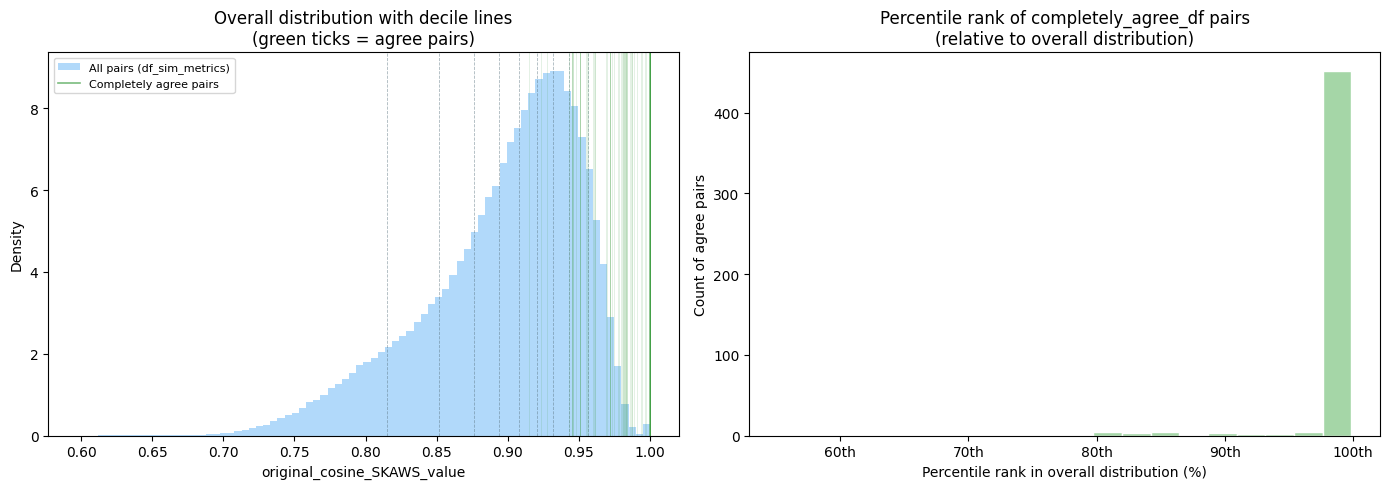


Agree pairs — percentile rank summary (n=477):
count    477.0
mean      99.1
std        4.1
min       55.2
25%       99.9
50%       99.9
75%       99.9
max       99.9
Name: pct_rank, dtype: float64


In [32]:
# Percentile analysis — Completely Agree
overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
pct_levels = np.arange(0, 101, 10)
pct_values = np.percentile(overall, pct_levels)

agree_vals = agree_final_pairs["original_cosine_SKAWS_value"].dropna()
agree_percentile_ranks = np.array([(overall < v).mean() * 100 for v in agree_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(overall, bins=80, color="#90CAF9", edgecolor="none", alpha=0.7,
        density=True, label="All pairs (df_sim_metrics)")
for v in pct_values[1:-1]:
    ax.axvline(v, color="#546E7A", linewidth=0.6, linestyle="--", alpha=0.5)
for v in agree_vals:
    ax.axvline(v, color="#43A047", linewidth=0.4, alpha=0.25)
ax.axvline(agree_vals.iloc[0], color="#43A047", linewidth=1.2, alpha=0.7,
           label="Completely agree pairs")
ax.set_title("Overall distribution with decile lines\n(green ticks = agree pairs)")
ax.set_xlabel("original_cosine_SKAWS_value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(agree_percentile_ranks, bins=20, color="#A5D6A7", edgecolor="white")
ax2.set_title("Percentile rank of completely_agree_df pairs\n(relative to overall distribution)")
ax2.set_xlabel("Percentile rank in overall distribution (%)")
ax2.set_ylabel("Count of agree pairs")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}th"))

plt.tight_layout()
plt.show()

print(f"\nAgree pairs — percentile rank summary (n={len(agree_vals)}):")
print(pd.Series(agree_percentile_ranks, name="pct_rank").describe().round(1))

In [33]:
# Example pairs with 99th percentile values — Completely Agree
overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
p99 = np.percentile(overall, 99)
print(f"99th percentile threshold (overall): {p99:.4f}")

agree_top_pairs = agree_final_pairs[agree_final_pairs["original_cosine_SKAWS_value"] >= p99][["ONET_2019", "human_soc", "original_cosine_SKAWS_value"]]
agree_top_pairs = dedupe_unordered_pairs(agree_top_pairs, "ONET_2019", "human_soc", "original_cosine_SKAWS_value")
agree_top_pairs = agree_top_pairs.sort_values("original_cosine_SKAWS_value", ascending=False)

print(f"\nAgree pairs at or above 99th percentile (unique unordered pairs, n={len(agree_top_pairs)}):")
display(agree_top_pairs)

99th percentile threshold (overall): 0.9775

Agree pairs at or above 99th percentile (unique unordered pairs, n=195):


,ONET_2019,human_soc,original_cosine_SKAWS_value
508,53-6021,53-6021,1.000000
507,53-3032,53-3032,1.000000
505,53-7062,53-7062,1.000000
503,53-7065,53-7065,1.000000
502,53-3052,53-3052,1.000000
...,...,...,...
419,45-2092,45-2093,0.980775
158,25-4011,25-4012,0.980346
71,17-3012,17-3013,0.979361
63,17-3023,17-3024,0.978119


## Partially Agree
Build pair-level similarity table:
- Extracts and normalizes human SOC codes from `Human options 6-digit`
- Normalizes Lightcast SOC from `ONET_2019`
- Creates one row per `(ONET_2019, human SOC)` pair
- Joins to `df_sim_metrics` to pull `cosine_SKAWS_value`

In [34]:
# Build pair-level similarity table for partially_agree_df
partial_work = partially_agree_df.copy()
partial_work["ONET_2019_norm"] = partial_work["ONET_2019"].apply(normalize_soc)
partial_work["human_soc_list"] = partial_work["Human options 6-digit"].apply(extract_human_soc_list)

partial_pairs = (
    partial_work
    .explode("human_soc_list")
    .rename(columns={"human_soc_list": "human_soc"})
)
partial_pairs = partial_pairs[
    partial_pairs["ONET_2019_norm"].notna() & partial_pairs["human_soc"].notna()
].copy()

partial_m1 = partial_pairs.merge(
    sim,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["origin_soc_norm", "destination_soc_norm"],
    how="left"
).rename(columns={"original_cosine_SKAWS_value": "cosine_A"})

partial_m2 = partial_pairs.merge(
    sim,
    left_on=["ONET_2019_norm", "human_soc"],
    right_on=["destination_soc_norm", "origin_soc_norm"],
    how="left"
).rename(columns={"original_cosine_SKAWS_value": "cosine_B"})

partial_result = partial_m1.copy()
partial_result["original_cosine_SKAWS_value"] = partial_result["cosine_A"].combine_first(partial_m2["cosine_B"])
partial_result["match_direction"] = np.where(
    partial_result["cosine_A"].notna(), "A: ONET_2019->human",
    np.where(partial_m2["cosine_B"].notna(), "B: human->ONET_2019", "no_match")
)

partial_final_pairs = partial_result[[
    "ONET_2019", "ONET_2019_norm", "human_soc", "original_cosine_SKAWS_value", "match_direction"
]].copy()

print("Rows in pair-level output:", len(partial_final_pairs))
print("Pairs with similarity found:", partial_final_pairs["original_cosine_SKAWS_value"].notna().sum())
partial_final_pairs.head(10)

Rows in pair-level output: 274
Pairs with similarity found: 232


,ONET_2019,ONET_2019_norm,human_soc,original_cosine_SKAWS_value,match_direction
0,11-9051,11-9051,35-1012,0.988097,A: ONET_2019->human
1,11-9051,11-9051,11-9051,1.000000,A: ONET_2019->human
2,11-9051,11-9051,11-9051,1.000000,A: ONET_2019->human
3,11-9051,11-9051,35-1011,0.973801,A: ONET_2019->human
4,11-3061,11-3061,11-3061,1.000000,A: ONET_2019->human
5,11-3061,11-3061,11-3071,0.982334,A: ONET_2019->human
6,11-3121,11-3121,11-3121,1.000000,A: ONET_2019->human
7,11-3121,11-3121,11-1021,0.964391,A: ONET_2019->human
8,11-9111,11-9111,11-1011,0.980921,A: ONET_2019->human
9,11-9111,11-9111,11-9111,1.000000,A: ONET_2019->human


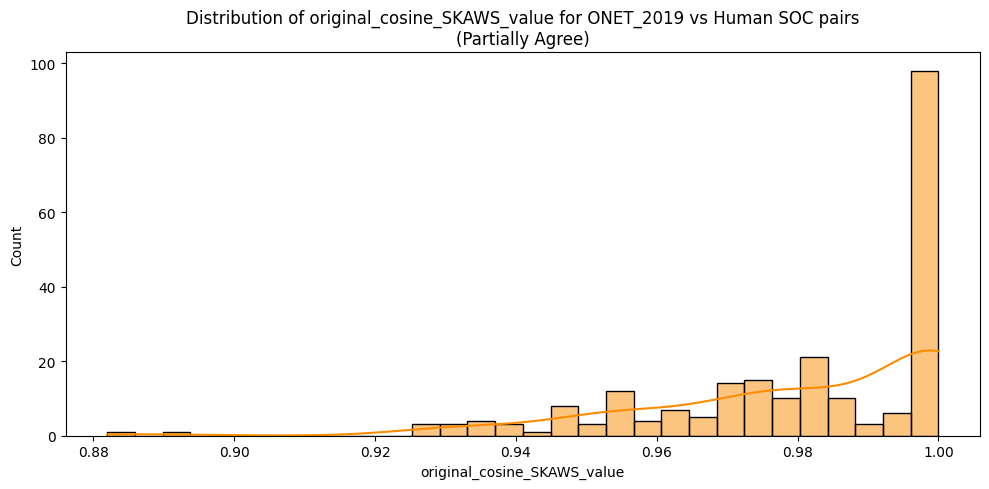

In [35]:
# Distribution of similarity scores — Partially Agree
partial_plot_df = partial_final_pairs[partial_final_pairs["original_cosine_SKAWS_value"].notna()].copy()

plt.figure(figsize=(10, 5))
sns.histplot(partial_plot_df["original_cosine_SKAWS_value"], bins=30, kde=True, color="#FB8C00")
plt.title("Distribution of original_cosine_SKAWS_value for ONET_2019 vs Human SOC pairs\n(Partially Agree)")
plt.xlabel("original_cosine_SKAWS_value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

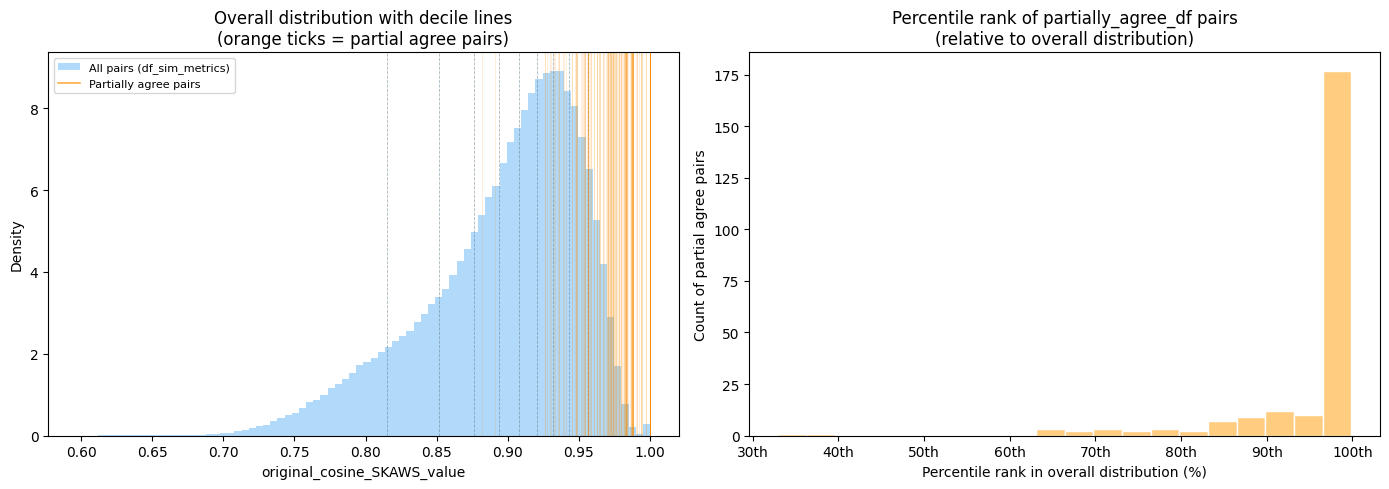


Partially agree pairs — percentile rank summary (n=232):
count    232.0
mean      95.6
std        9.3
min       33.0
25%       97.2
50%       99.8
75%       99.9
max       99.9
Name: pct_rank, dtype: float64


In [36]:
# Percentile analysis — Partially Agree
overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
pct_levels = np.arange(0, 101, 10)
pct_values = np.percentile(overall, pct_levels)

partial_vals = partial_final_pairs["original_cosine_SKAWS_value"].dropna()
partial_percentile_ranks = np.array([(overall < v).mean() * 100 for v in partial_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(overall, bins=80, color="#90CAF9", edgecolor="none", alpha=0.7,
        density=True, label="All pairs (df_sim_metrics)")
for v in pct_values[1:-1]:
    ax.axvline(v, color="#546E7A", linewidth=0.6, linestyle="--", alpha=0.5)
for v in partial_vals:
    ax.axvline(v, color="#FB8C00", linewidth=0.4, alpha=0.25)
ax.axvline(partial_vals.iloc[0], color="#FB8C00", linewidth=1.2, alpha=0.7,
           label="Partially agree pairs")
ax.set_title("Overall distribution with decile lines\n(orange ticks = partial agree pairs)")
ax.set_xlabel("original_cosine_SKAWS_value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(partial_percentile_ranks, bins=20, color="#FFCC80", edgecolor="white")
ax2.set_title("Percentile rank of partially_agree_df pairs\n(relative to overall distribution)")
ax2.set_xlabel("Percentile rank in overall distribution (%)")
ax2.set_ylabel("Count of partial agree pairs")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}th"))

plt.tight_layout()
plt.show()

print(f"\nPartially agree pairs — percentile rank summary (n={len(partial_vals)}):")
print(pd.Series(partial_percentile_ranks, name="pct_rank").describe().round(1))

In [37]:
# Example pairs with 99th percentile values — Partially Agree
overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
p99 = np.percentile(overall, 99)
print(f"99th percentile threshold (overall): {p99:.4f}")

partial_top_pairs = partial_final_pairs[partial_final_pairs["original_cosine_SKAWS_value"] >= p99][["ONET_2019", "human_soc", "original_cosine_SKAWS_value"]]
partial_top_pairs = dedupe_unordered_pairs(partial_top_pairs, "ONET_2019", "human_soc", "original_cosine_SKAWS_value")
partial_top_pairs = partial_top_pairs.sort_values("original_cosine_SKAWS_value", ascending=False)

print(f"\nPartially agree pairs at or above 99th percentile (unique unordered pairs, n={len(partial_top_pairs)}):")
display(partial_top_pairs)

99th percentile threshold (overall): 0.9775

Partially agree pairs at or above 99th percentile (unique unordered pairs, n=109):


,ONET_2019,human_soc,original_cosine_SKAWS_value
1,11-9051,11-9051,1.000000
4,11-3061,11-3061,1.000000
28,13-1161,13-1161,1.000000
6,11-3121,11-3121,1.000000
11,13-1082,13-1082,1.000000
...,...,...,...
250,49-9041,49-9071,0.978657
55,15-1241,15-1299,0.978449
81,19-1021,19-1022,0.978209
40,13-1082,15-1299,0.978020


### Plot 1 — Pairwise Similarities Between the Human Coder's Own Chosen Codes
For each partial agreement row, compute the pairwise `cosine_SKAWS_value` between all combinations of the human coder's selected SOC codes (e.g. if 3 codes were chosen, this gives 3 pairs). Plot those similarity values against the overall decile distribution.

Human-to-human unique unordered pairs: 174, matched: 144


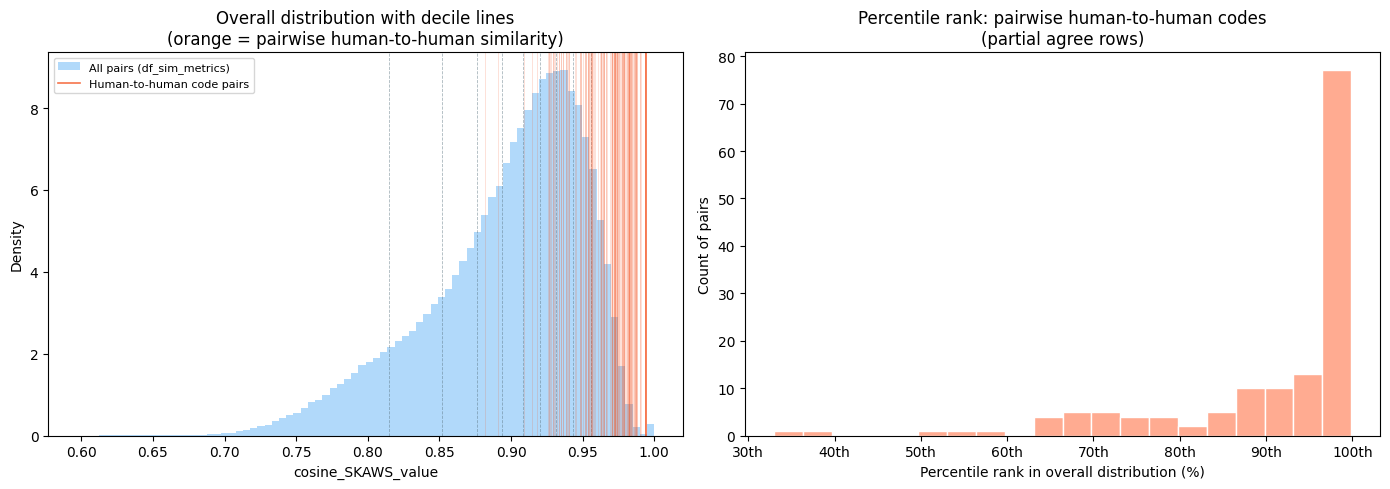


Human-to-human code pairs — percentile rank summary (n=144):
count    144.0
mean      90.5
std       13.1
min       33.0
25%       87.0
50%       97.4
75%       99.5
max       99.9
Name: pct_rank, dtype: float64


In [38]:
from itertools import combinations

# Plot 1: Pairwise similarities between the human coder's own chosen codes
human_pairs_rows = []

for _, row in partially_agree_df.iterrows():
    codes = extract_human_soc_list(row["Human options 6-digit"])
    for code_a, code_b in combinations(codes, 2):
        fwd = sim[
            (sim["origin_soc_norm"] == code_a) & (sim["destination_soc_norm"] == code_b)
        ]
        rev = sim[
            (sim["origin_soc_norm"] == code_b) & (sim["destination_soc_norm"] == code_a)
        ]
        match = fwd if len(fwd) > 0 else rev
        val = match["original_cosine_SKAWS_value"].iloc[0] if len(match) > 0 else np.nan
        human_pairs_rows.append({
            "human_soc_a": code_a,
            "human_soc_b": code_b,
            "original_cosine_SKAWS_value": val
        })

human_pairs_df = pd.DataFrame(human_pairs_rows)
human_pairs_df = dedupe_unordered_pairs(human_pairs_df, "human_soc_a", "human_soc_b", "original_cosine_SKAWS_value")

print(f"Human-to-human unique unordered pairs: {len(human_pairs_df)}, matched: {human_pairs_df['original_cosine_SKAWS_value'].notna().sum()}")

overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
pct_levels = np.arange(0, 101, 10)
pct_values = np.percentile(overall, pct_levels)

h2h_vals = human_pairs_df["original_cosine_SKAWS_value"].dropna()
h2h_pct_ranks = np.array([(overall < v).mean() * 100 for v in h2h_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(overall, bins=80, color="#90CAF9", edgecolor="none", alpha=0.7,
        density=True, label="All pairs (df_sim_metrics)")
for v in pct_values[1:-1]:
    ax.axvline(v, color="#546E7A", linewidth=0.6, linestyle="--", alpha=0.5)
for v in h2h_vals:
    ax.axvline(v, color="#F4511E", linewidth=0.4, alpha=0.3)
ax.axvline(h2h_vals.iloc[0], color="#F4511E", linewidth=1.2, alpha=0.8,
           label="Human-to-human code pairs")
ax.set_title("Overall distribution with decile lines\n(orange = pairwise human-to-human similarity)")
ax.set_xlabel("cosine_SKAWS_value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(h2h_pct_ranks, bins=20, color="#FFAB91", edgecolor="white")
ax2.set_title("Percentile rank: pairwise human-to-human codes\n(partial agree rows)")
ax2.set_xlabel("Percentile rank in overall distribution (%)")
ax2.set_ylabel("Count of pairs")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}th"))

plt.tight_layout()
plt.show()

print(f"\nHuman-to-human code pairs — percentile rank summary (n={len(h2h_vals)}):")
print(pd.Series(h2h_pct_ranks, name="pct_rank").describe().round(1))

### Plot 2 — Similarities Between ONET_2019 and Non-Matching Human Codes
For partial agreement rows, filter to only the human-chosen codes that are **not** the same as the Lightcast `ONET_2019` code, and plot those similarity values against the overall decile distribution.

Non-matching unique unordered pairs (partial agree): 120


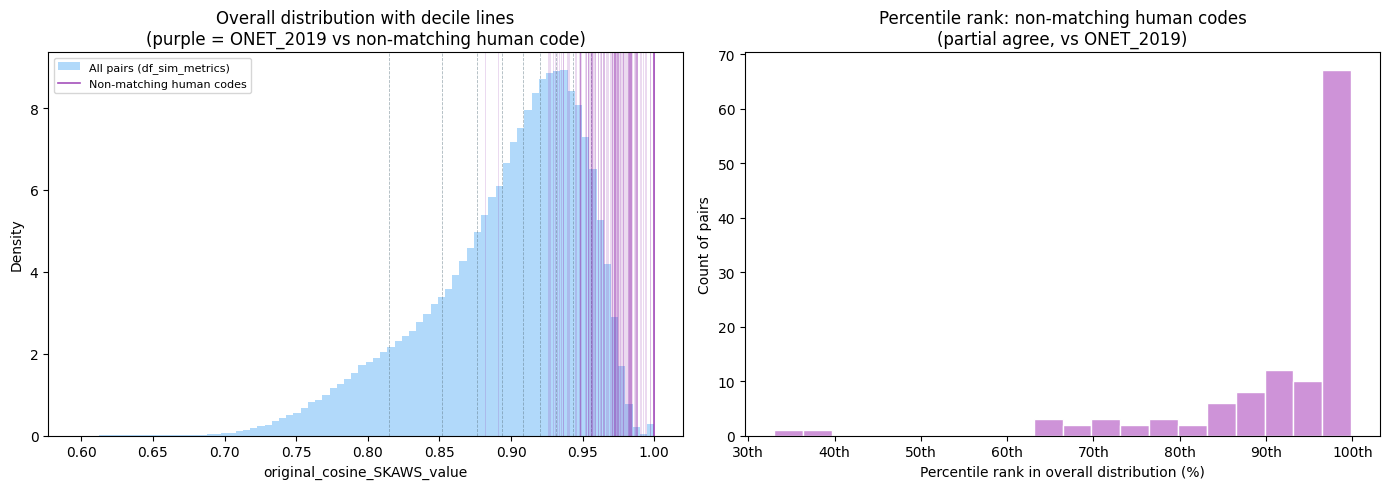


Non-matching human code pairs — percentile rank summary (n=120):
count    120.0
mean      92.0
std       11.7
min       33.0
25%       89.2
50%       97.7
75%       99.6
max       99.9
Name: pct_rank, dtype: float64


In [39]:
# Plot 2: Similarities for non-matching human codes only
# Keep only one record per unordered pair where human code differs from ONET_2019
non_match = partial_final_pairs[
    partial_final_pairs["original_cosine_SKAWS_value"].notna() &
    (partial_final_pairs["human_soc"] != partial_final_pairs["ONET_2019_norm"])
][["ONET_2019_norm", "human_soc", "original_cosine_SKAWS_value"]].copy()

non_match = dedupe_unordered_pairs(non_match, "ONET_2019_norm", "human_soc", "original_cosine_SKAWS_value")

print(f"Non-matching unique unordered pairs (partial agree): {len(non_match)}")

overall = df_sim_metrics["original_cosine_SKAWS_value"].dropna()
pct_levels = np.arange(0, 101, 10)
pct_values = np.percentile(overall, pct_levels)

non_match_vals = non_match["original_cosine_SKAWS_value"]
non_match_pct_ranks = np.array([(overall < v).mean() * 100 for v in non_match_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(overall, bins=80, color="#90CAF9", edgecolor="none", alpha=0.7,
        density=True, label="All pairs (df_sim_metrics)")
for v in pct_values[1:-1]:
    ax.axvline(v, color="#546E7A", linewidth=0.6, linestyle="--", alpha=0.5)
for v in non_match_vals:
    ax.axvline(v, color="#8E24AA", linewidth=0.4, alpha=0.3)
ax.axvline(non_match_vals.iloc[0], color="#8E24AA", linewidth=1.2, alpha=0.8,
           label="Non-matching human codes")
ax.set_title("Overall distribution with decile lines\n(purple = ONET_2019 vs non-matching human code)")
ax.set_xlabel("original_cosine_SKAWS_value")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(non_match_pct_ranks, bins=20, color="#CE93D8", edgecolor="white")
ax2.set_title("Percentile rank: non-matching human codes\n(partial agree, vs ONET_2019)")
ax2.set_xlabel("Percentile rank in overall distribution (%)")
ax2.set_ylabel("Count of pairs")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}th"))

plt.tight_layout()
plt.show()

print(f"\nNon-matching human code pairs — percentile rank summary (n={len(non_match_vals)}):")
print(pd.Series(non_match_pct_ranks, name="pct_rank").describe().round(1))

# Missing Pairs Analysis

In [40]:
missing_summary = {
    "total_pairs": len(final_pairs),
    "matched_pairs": int(final_pairs["original_cosine_SKAWS_value"].notna().sum()),
    "missing_pairs": int(final_pairs["original_cosine_SKAWS_value"].isna().sum()),
    "missing_share": float(final_pairs["original_cosine_SKAWS_value"].isna().mean())
}

print(missing_summary)

missing_pairs_df = final_pairs[final_pairs["original_cosine_SKAWS_value"].isna()].copy()
print("\nMissing pair examples:")
display(missing_pairs_df.head(10))

sim_keys = set(zip(sim["origin_soc_norm"], sim["destination_soc_norm"]))
sim_keys_rev = set(zip(sim["destination_soc_norm"], sim["origin_soc_norm"]))

missing_pairs_df["pair_in_sim_forward"] = missing_pairs_df.apply(
    lambda row: (row["ONET_2019_norm"], row["human_soc"]) in sim_keys,
    axis=1
)
missing_pairs_df["pair_in_sim_reverse"] = missing_pairs_df.apply(
    lambda row: (row["ONET_2019_norm"], row["human_soc"]) in sim_keys_rev,
    axis=1
)

print("\nMissing rows where neither direction exists in df_sim_metrics:")
print((~missing_pairs_df["pair_in_sim_forward"] & ~missing_pairs_df["pair_in_sim_reverse"]).sum())

print("\nTop missing ONET_2019 codes:")
display(missing_pairs_df["ONET_2019_norm"].value_counts().head(10))

print("\nTop missing human SOC codes:")
display(missing_pairs_df["human_soc"].value_counts().head(10))

{'total_pairs': 498, 'matched_pairs': 382, 'missing_pairs': 116, 'missing_share': 0.23293172690763053}

Missing pair examples:


,ONET_2019,ONET_2019_norm,human_soc,original_cosine_SKAWS_value,match_direction
1,11-9111,11-9111,21-1014,NaN,no_match
39,13-1023,13-1023,13-1121,NaN,no_match
51,13-1023,13-1023,11-9111,NaN,no_match
54,13-2011,13-2011,41-3091,NaN,no_match
58,15-2051,15-2051,15-1240,NaN,no_match
61,15-1299,15-1299,15-1230,NaN,no_match
62,15-1243,15-1243,29-2072,NaN,no_match
74,15-1252,15-1252,15-1240,NaN,no_match
127,19-5012,19-5012,29-2043,NaN,no_match
135,21-1021,21-1021,25-9042,NaN,no_match



Missing rows where neither direction exists in df_sim_metrics:
72

Top missing ONET_2019 codes:


ONET_2019_norm
99-9999    42
45-3031    31
31-1122     5
41-3091     4
49-9071     3
51-9082     3
13-1023     2
21-1021     2
25-9049     2
29-1299     2
Name: count, dtype: int64


Top missing human SOC codes:


human_soc
41-3091    5
15-1240    3
21-1093    3
49-9040    3
21-1014    2
11-9111    2
25-9042    2
23-2099    2
21-1011    2
11-3013    2
Name: count, dtype: int64

In [41]:
missing_pairs_df = final_pairs[final_pairs["original_cosine_SKAWS_value"].isna()].copy()

forward_exists = missing_pairs_df.apply(
    lambda row: ((sim["origin_soc_norm"] == row["ONET_2019_norm"]) & (sim["destination_soc_norm"] == row["human_soc"])).any(),
    axis=1
)
reverse_exists = missing_pairs_df.apply(
    lambda row: ((sim["destination_soc_norm"] == row["ONET_2019_norm"]) & (sim["origin_soc_norm"] == row["human_soc"])).any(),
    axis=1
)

print({
    "missing_pairs_not_in_sim_at_all": int((~forward_exists & ~reverse_exists).sum()),
    "missing_pairs_present_in_sim_but_similarity_missing": int((forward_exists | reverse_exists).sum())
})

{'missing_pairs_not_in_sim_at_all': 72, 'missing_pairs_present_in_sim_but_similarity_missing': 44}


In [42]:
df_check=df_sim_metrics[df_sim_metrics['origin_soc']=='11-9111']
df_check2=df_sim_metrics[df_sim_metrics['destination_soc']=='21-1014']

#spot check--yes it is true, for instance, that 11-911 and 21-1014 are not in the sim metrics as a pair


# Overall Distribution Similarity by Two-Digit, 4-Digit-, 6-Digit SOC Code

Rows excluded (all groups outside exact 2/4/5): 581,709


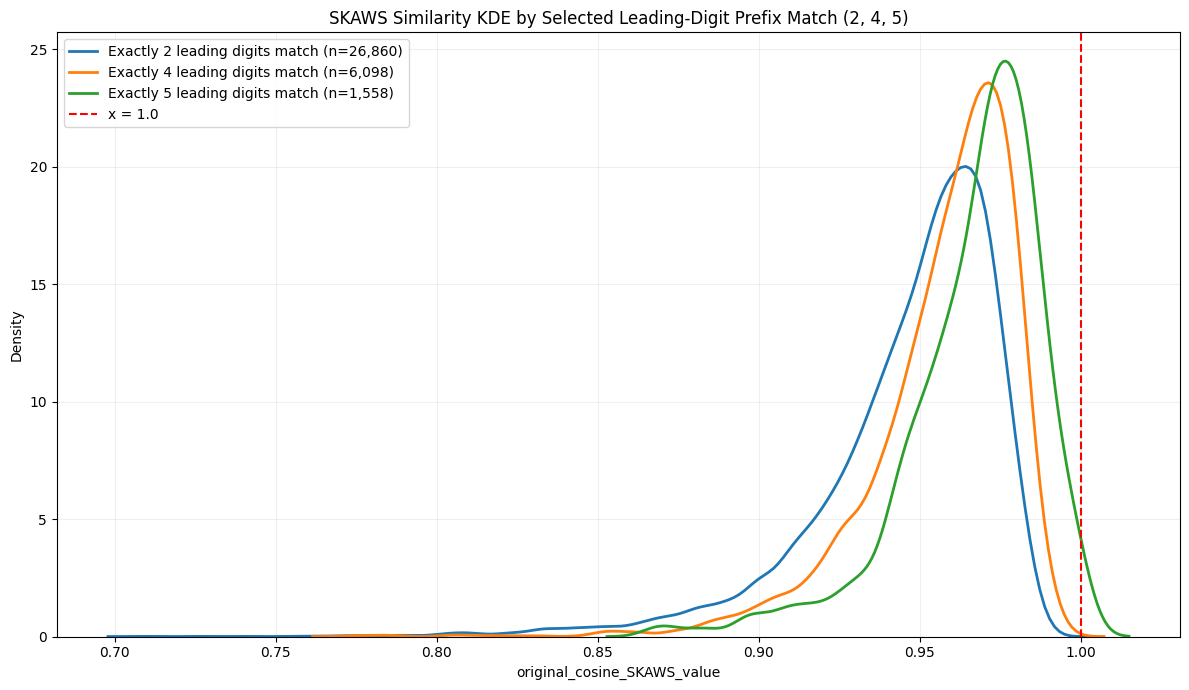

,group,count,mean_similarity
0,Exactly 2 leading digits match,26860,0.946460
1,Exactly 4 leading digits match,6098,0.957371
2,Exactly 5 leading digits match,1558,0.966819


In [43]:
import seaborn as sns

sim_dist = df_sim_metrics[["origin_soc", "destination_soc", "original_cosine_SKAWS_value"]].copy()

sim_dist["origin_norm"] = sim_dist["origin_soc"].apply(normalize_soc)
sim_dist["destination_norm"] = sim_dist["destination_soc"].apply(normalize_soc)
sim_dist = sim_dist.dropna(subset=["origin_norm", "destination_norm", "original_cosine_SKAWS_value"]).copy()

sim_dist["origin_digits"] = sim_dist["origin_norm"].str.replace("-", "", regex=False)
sim_dist["destination_digits"] = sim_dist["destination_norm"].str.replace("-", "", regex=False)

sim_dist = sim_dist[
    sim_dist["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & sim_dist["destination_digits"].str.fullmatch(r"\d{6}", na=False)
]

# Exact prefix-match buckets (first k digits match, then diverge at k+1).
same_1 = sim_dist["origin_digits"].str[:1] == sim_dist["destination_digits"].str[:1]
same_2 = sim_dist["origin_digits"].str[:2] == sim_dist["destination_digits"].str[:2]
same_3 = sim_dist["origin_digits"].str[:3] == sim_dist["destination_digits"].str[:3]
same_4 = sim_dist["origin_digits"].str[:4] == sim_dist["destination_digits"].str[:4]
same_5 = sim_dist["origin_digits"].str[:5] == sim_dist["destination_digits"].str[:5]
same_6 = sim_dist["origin_digits"] == sim_dist["destination_digits"]

exact_0 = ~same_1
exact_1 = same_1 & ~same_2
exact_2 = same_2 & ~same_3
exact_3 = same_3 & ~same_4
exact_4 = same_4 & ~same_5
exact_5 = same_5 & ~same_6

line_groups = [
    ("Exactly 2 leading digits match", exact_2, "#1f77b4"),
    ("Exactly 4 leading digits match", exact_4, "#ff7f0e"),
    ("Exactly 5 leading digits match", exact_5, "#2ca02c"),
]

plt.figure(figsize=(12, 7))
summary_rows = []

for label, mask, color in line_groups:
    vals = sim_dist.loc[mask, "original_cosine_SKAWS_value"].dropna()
    if len(vals) > 1 and vals.nunique() > 1:
        sns.kdeplot(vals, bw_adjust=1.0, linewidth=2, color=color, label=f"{label} (n={len(vals):,})")
    summary_rows.append({
        "group": label,
        "count": int(mask.sum()),
        "mean_similarity": float(vals.mean()) if len(vals) > 0 else np.nan,
    })

selected_mask = pd.Series(False, index=sim_dist.index)
for _, mask, _ in line_groups:
    selected_mask = selected_mask | mask

excluded = int((~selected_mask).sum())
print(f"Rows excluded (all groups outside exact 2/4/5): {excluded:,}")

plt.title("SKAWS Similarity KDE by Selected Leading-Digit Prefix Match (2, 4, 5)")
plt.xlabel("original_cosine_SKAWS_value")
plt.ylabel("Density")
plt.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="x = 1.0")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(summary_rows))


Rows excluded (all groups outside exact 2/4/5): 581,709


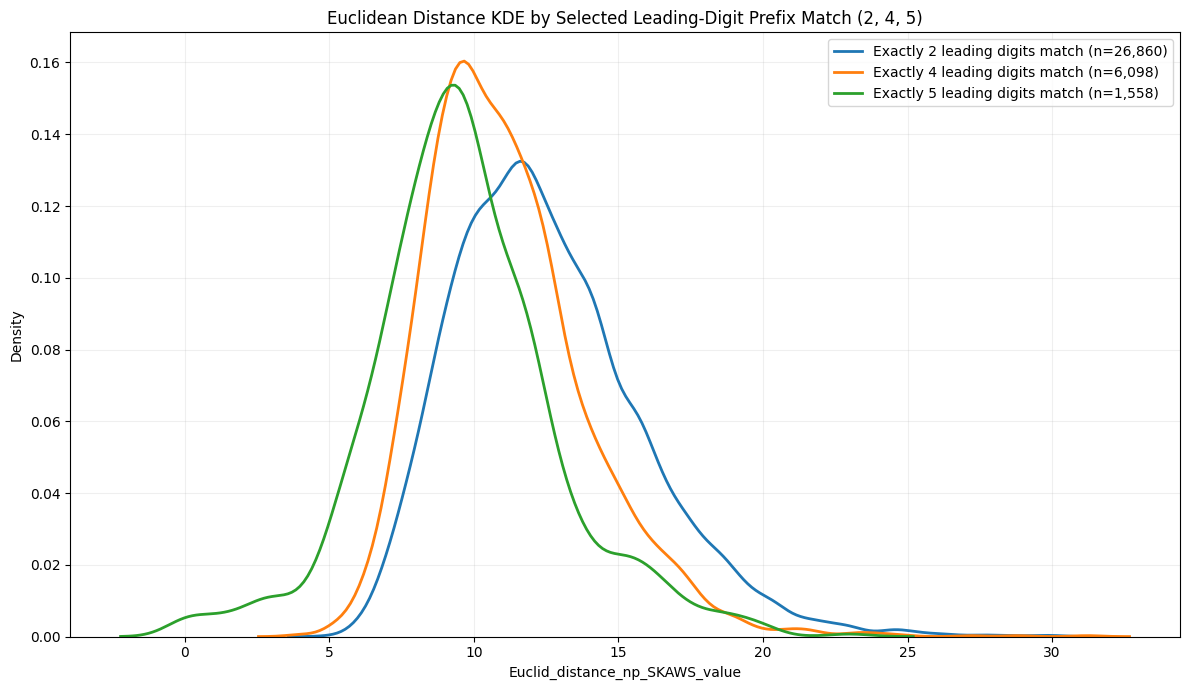

,group,count,mean_distance
0,Exactly 2 leading digits match,26860,12.534979
1,Exactly 4 leading digits match,6098,11.123474
2,Exactly 5 leading digits match,1558,9.612395


In [44]:
# Euclidean distance KDE by selected leading-digit prefix match (2, 4, 5)
euclid_dist = df_sim_metrics[["origin_soc", "destination_soc", "Euclid_distance_np_SKAWS_value"]].copy()

euclid_dist["origin_norm"] = euclid_dist["origin_soc"].apply(normalize_soc)
euclid_dist["destination_norm"] = euclid_dist["destination_soc"].apply(normalize_soc)
euclid_dist = euclid_dist.dropna(subset=["origin_norm", "destination_norm", "Euclid_distance_np_SKAWS_value"]).copy()

euclid_dist["origin_digits"] = euclid_dist["origin_norm"].str.replace("-", "", regex=False)
euclid_dist["destination_digits"] = euclid_dist["destination_norm"].str.replace("-", "", regex=False)

euclid_dist = euclid_dist[
    euclid_dist["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & euclid_dist["destination_digits"].str.fullmatch(r"\d{6}", na=False)
]

# Exact prefix-match buckets (first k digits match, then diverge at k+1).
same_1 = euclid_dist["origin_digits"].str[:1] == euclid_dist["destination_digits"].str[:1]
same_2 = euclid_dist["origin_digits"].str[:2] == euclid_dist["destination_digits"].str[:2]
same_3 = euclid_dist["origin_digits"].str[:3] == euclid_dist["destination_digits"].str[:3]
same_4 = euclid_dist["origin_digits"].str[:4] == euclid_dist["destination_digits"].str[:4]
same_5 = euclid_dist["origin_digits"].str[:5] == euclid_dist["destination_digits"].str[:5]
same_6 = euclid_dist["origin_digits"] == euclid_dist["destination_digits"]

exact_0 = ~same_1
exact_1 = same_1 & ~same_2
exact_2 = same_2 & ~same_3
exact_3 = same_3 & ~same_4
exact_4 = same_4 & ~same_5
exact_5 = same_5 & ~same_6

line_groups = [
    ("Exactly 2 leading digits match", exact_2, "#1f77b4"),
    ("Exactly 4 leading digits match", exact_4, "#ff7f0e"),
    ("Exactly 5 leading digits match", exact_5, "#2ca02c"),
]

plt.figure(figsize=(12, 7))
summary_rows = []

for label, mask, color in line_groups:
    vals = euclid_dist.loc[mask, "Euclid_distance_np_SKAWS_value"].dropna()
    if len(vals) > 1 and vals.nunique() > 1:
        sns.kdeplot(vals, bw_adjust=1.0, linewidth=2, color=color, label=f"{label} (n={len(vals):,})")
    summary_rows.append({
        "group": label,
        "count": int(mask.sum()),
        "mean_distance": float(vals.mean()) if len(vals) > 0 else np.nan,
    })

selected_mask = pd.Series(False, index=euclid_dist.index)
for _, mask, _ in line_groups:
    selected_mask = selected_mask | mask

excluded = int((~selected_mask).sum())
print(f"Rows excluded (all groups outside exact 2/4/5): {excluded:,}")

plt.title("Euclidean Distance KDE by Selected Leading-Digit Prefix Match (2, 4, 5)")
plt.xlabel("Euclid_distance_np_SKAWS_value")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(summary_rows))


Rows excluded (exact 6 leading-digit matches): 758


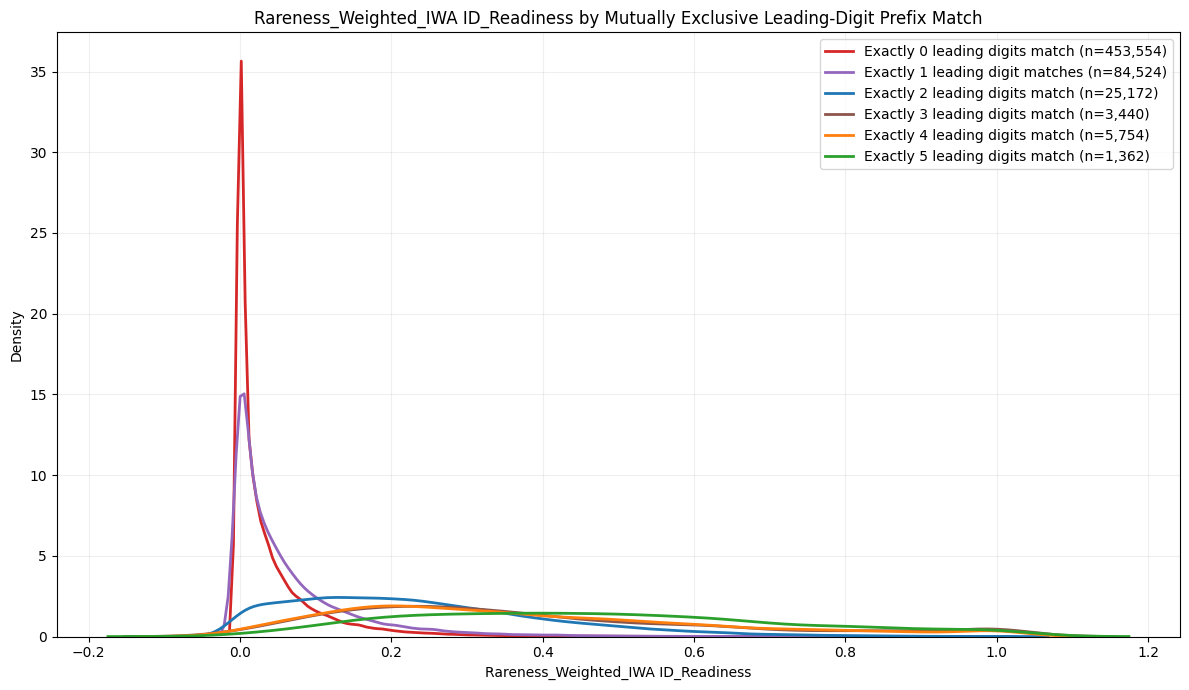

,group,count,mean_value
0,Exactly 0 leading digits match,453554,0.037703
1,Exactly 1 leading digit matches,84524,0.061949
2,Exactly 2 leading digits match,25172,0.237206
3,Exactly 3 leading digits match,3440,0.387886
4,Exactly 4 leading digits match,5754,0.377595
5,Exactly 5 leading digits match,1362,0.472209


In [45]:

readiness_col = "Rareness_Weighted_IWA ID_Readiness"

if readiness_col not in df_sim_metrics.columns:
    raise KeyError(
        f"Column '{readiness_col}' not found in df_sim_metrics. Available columns include: "
        + ", ".join(df_sim_metrics.columns[:20])
    )

readiness_dist = df_sim_metrics[["origin_soc", "destination_soc", readiness_col]].copy()
readiness_dist["origin_norm"] = readiness_dist["origin_soc"].apply(normalize_soc)
readiness_dist["destination_norm"] = readiness_dist["destination_soc"].apply(normalize_soc)
readiness_dist = readiness_dist.dropna(subset=["origin_norm", "destination_norm", readiness_col]).copy()

readiness_dist["origin_digits"] = readiness_dist["origin_norm"].str.replace("-", "", regex=False)
readiness_dist["destination_digits"] = readiness_dist["destination_norm"].str.replace("-", "", regex=False)

readiness_dist = readiness_dist[
    readiness_dist["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & readiness_dist["destination_digits"].str.fullmatch(r"\d{6}", na=False)
]

same_1 = readiness_dist["origin_digits"].str[:1] == readiness_dist["destination_digits"].str[:1]
same_2 = readiness_dist["origin_digits"].str[:2] == readiness_dist["destination_digits"].str[:2]
same_3 = readiness_dist["origin_digits"].str[:3] == readiness_dist["destination_digits"].str[:3]
same_4 = readiness_dist["origin_digits"].str[:4] == readiness_dist["destination_digits"].str[:4]
same_5 = readiness_dist["origin_digits"].str[:5] == readiness_dist["destination_digits"].str[:5]
same_6 = readiness_dist["origin_digits"] == readiness_dist["destination_digits"]

exact_0 = ~same_1
exact_1 = same_1 & ~same_2
exact_2 = same_2 & ~same_3
exact_3 = same_3 & ~same_4
exact_4 = same_4 & ~same_5
exact_5 = same_5 & ~same_6

line_groups = [
    ("Exactly 0 leading digits match", exact_0, "#d62728"),
    ("Exactly 1 leading digit matches", exact_1, "#9467bd"),
    ("Exactly 2 leading digits match", exact_2, "#1f77b4"),
    ("Exactly 3 leading digits match", exact_3, "#8c564b"),
    ("Exactly 4 leading digits match", exact_4, "#ff7f0e"),
    ("Exactly 5 leading digits match", exact_5, "#2ca02c"),
]

plt.figure(figsize=(12, 7))
summary_rows = []

for label, mask, color in line_groups:
    vals = readiness_dist.loc[mask, readiness_col].dropna()
    if len(vals) > 1 and vals.nunique() > 1:
        sns.kdeplot(vals, bw_adjust=1.0, linewidth=2, color=color, label=f"{label} (n={len(vals):,})")
    summary_rows.append({
        "group": label,
        "count": int(mask.sum()),
        "mean_value": float(vals.mean()) if len(vals) > 0 else np.nan,
    })

selected_mask = pd.Series(False, index=readiness_dist.index)
for _, mask, _ in line_groups:
    selected_mask = selected_mask | mask

excluded = int((~selected_mask).sum())
print(f"Rows excluded (exact 6 leading-digit matches): {excluded:,}")

plt.title("Rareness_Weighted_IWA ID_Readiness by Mutually Exclusive Leading-Digit Prefix Match")
plt.xlabel(readiness_col)
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(summary_rows))

## Next Step: Neighbor Similarity at 2-, 4-, and 5-Digit SOC Levels
Characterize similarity among occupational neighbors at hierarchical SOC levels, and nest the analysis within each 2-digit major group (for example, compare 21s vs 53s).

Overall neighbor similarity summary (2/4/5-digit):


,level,count,mean_similarity,median_similarity,p25,p75
0,2-digit neighbors,38891,0.951363,0.957340,0.939351,0.969839
1,4-digit neighbors,8441,0.963079,0.966934,0.951098,0.978431
2,5-digit neighbors,2343,0.977936,0.981621,0.965577,1.000000


Nested summary by 2-digit major group (first rows):


,major_group,level,count,mean_similarity,median_similarity
0,11,2-digit neighbors,1225,0.964368,0.967230
1,11,4-digit neighbors,273,0.969599,0.970757
2,11,5-digit neighbors,55,0.995681,1.000000
3,13,2-digit neighbors,1024,0.956179,0.962319
4,13,4-digit neighbors,366,0.964194,0.970861
5,13,5-digit neighbors,58,0.985216,1.000000
6,15,2-digit neighbors,441,0.959951,0.963428
7,15,4-digit neighbors,261,0.971163,0.974253
8,15,5-digit neighbors,57,0.985815,0.985722
9,17,2-digit neighbors,1296,0.960124,0.962682


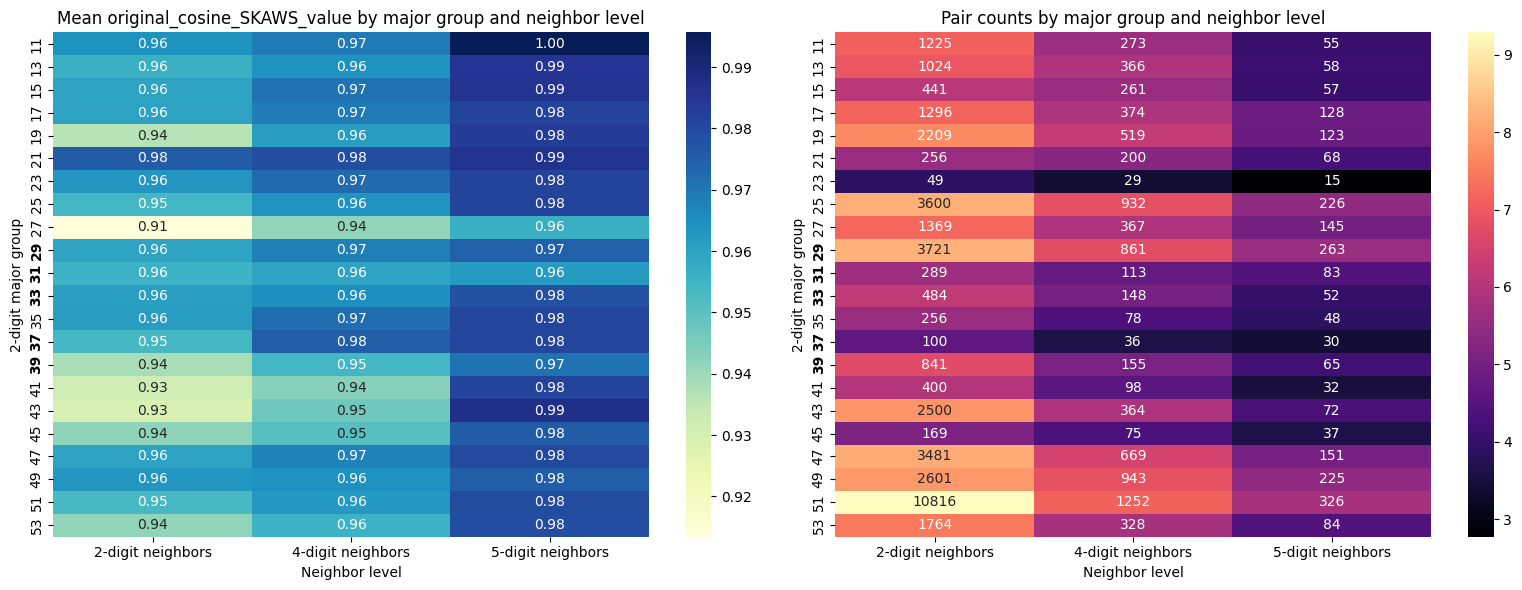

In [46]:
neighbor_df = df_sim_metrics[["origin_soc", "destination_soc", "original_cosine_SKAWS_value"]].copy()
neighbor_df["origin_norm"] = neighbor_df["origin_soc"].apply(normalize_soc)
neighbor_df["destination_norm"] = neighbor_df["destination_soc"].apply(normalize_soc)
neighbor_df = neighbor_df.dropna(subset=["origin_norm", "destination_norm", "original_cosine_SKAWS_value"]).copy()

neighbor_df["origin_digits"] = neighbor_df["origin_norm"].str.replace("-", "", regex=False)
neighbor_df["destination_digits"] = neighbor_df["destination_norm"].str.replace("-", "", regex=False)
neighbor_df = neighbor_df[
    neighbor_df["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & neighbor_df["destination_digits"].str.fullmatch(r"\d{6}", na=False)
]

# Explicit prefix checks: same FIRST 2/4/5 digits.
neighbor_df["same_2"] = neighbor_df["origin_digits"].str.slice(0, 2).eq(
    neighbor_df["destination_digits"].str.slice(0, 2)
)
neighbor_df["same_4"] = neighbor_df["origin_digits"].str.slice(0, 4).eq(
    neighbor_df["destination_digits"].str.slice(0, 4)
)
neighbor_df["same_5"] = neighbor_df["origin_digits"].str.slice(0, 5).eq(
    neighbor_df["destination_digits"].str.slice(0, 5)
)

# Sanity checks for hierarchical prefixes.
assert neighbor_df.loc[neighbor_df["same_5"], "same_4"].all()
assert neighbor_df.loc[neighbor_df["same_4"], "same_2"].all()

level_specs = [
    ("2-digit neighbors", "same_2"),
    ("4-digit neighbors", "same_4"),
    ("5-digit neighbors", "same_5"),
]

overall_rows = []
for level_name, level_col in level_specs:
    vals = neighbor_df.loc[neighbor_df[level_col], "original_cosine_SKAWS_value"].dropna()
    overall_rows.append({
        "level": level_name,
        "count": int(len(vals)),
        "mean_similarity": float(vals.mean()) if len(vals) else np.nan,
        "median_similarity": float(vals.median()) if len(vals) else np.nan,
        "p25": float(vals.quantile(0.25)) if len(vals) else np.nan,
        "p75": float(vals.quantile(0.75)) if len(vals) else np.nan,
    })

overall_neighbor_summary = pd.DataFrame(overall_rows)
print("Overall neighbor similarity summary (2/4/5-digit):")
display(overall_neighbor_summary)

within_2digit = neighbor_df[neighbor_df["same_2"]].copy()
within_2digit["major_group"] = within_2digit["origin_digits"].str[:2]

nested_rows = []
for major_group, g in within_2digit.groupby("major_group", sort=True):
    for level_name, level_col in level_specs:
        vals = g.loc[g[level_col], "original_cosine_SKAWS_value"].dropna()
        nested_rows.append({
            "major_group": major_group,
            "level": level_name,
            "count": int(len(vals)),
            "mean_similarity": float(vals.mean()) if len(vals) else np.nan,
            "median_similarity": float(vals.median()) if len(vals) else np.nan,
        })

nested_neighbor_summary = pd.DataFrame(nested_rows)

print("Nested summary by 2-digit major group (first rows):")
display(nested_neighbor_summary.sort_values(["major_group", "level"]).head(24))

plot_df = nested_neighbor_summary.pivot(
    index="major_group", columns="level", values="mean_similarity"
).sort_index()

count_df = nested_neighbor_summary.pivot(
    index="major_group", columns="level", values="count"
).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(plot_df, cmap="YlGnBu", annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Mean original_cosine_SKAWS_value by major group and neighbor level")
axes[0].set_xlabel("Neighbor level")
axes[0].set_ylabel("2-digit major group")

sns.heatmap(np.log1p(count_df), cmap="magma", annot=count_df, fmt=".0f", ax=axes[1])
axes[1].set_title("Pair counts by major group and neighbor level")
axes[1].set_xlabel("Neighbor level")
axes[1].set_ylabel("2-digit major group")

highlight_codes = {"29", "33", "37", "31", "39"}
for ax in axes:
    for tick in ax.get_yticklabels():
        if tick.get_text() in highlight_codes:
            tick.set_fontweight("bold")

plt.tight_layout()
plt.show()


Overall Euclidean neighbor summary (2/4/5-digit):


,level,count,mean_distance,median_distance,p25,p75
0,2-digit neighbors,38891,11.809777,11.571855,9.611473,13.844904
1,4-digit neighbors,8441,9.810100,10.086783,8.347440,12.158344
2,5-digit neighbors,2343,6.391853,7.724007,0.000000,10.182904


Nested Euclidean summary by 2-digit major group (first rows):


,major_group,level,count,mean_distance,median_distance
0,11,2-digit neighbors,1225,10.967773,11.078884
1,11,4-digit neighbors,273,9.543763,10.490931
2,11,5-digit neighbors,55,2.079558,0.000000
3,13,2-digit neighbors,1024,11.102793,10.847283
4,13,4-digit neighbors,366,9.519025,9.747712
5,13,5-digit neighbors,58,3.557784,0.000000
6,15,2-digit neighbors,441,10.649614,10.811392
7,15,4-digit neighbors,261,9.015713,9.522846
8,15,5-digit neighbors,57,5.020976,6.900065
9,17,2-digit neighbors,1296,11.799815,12.063850


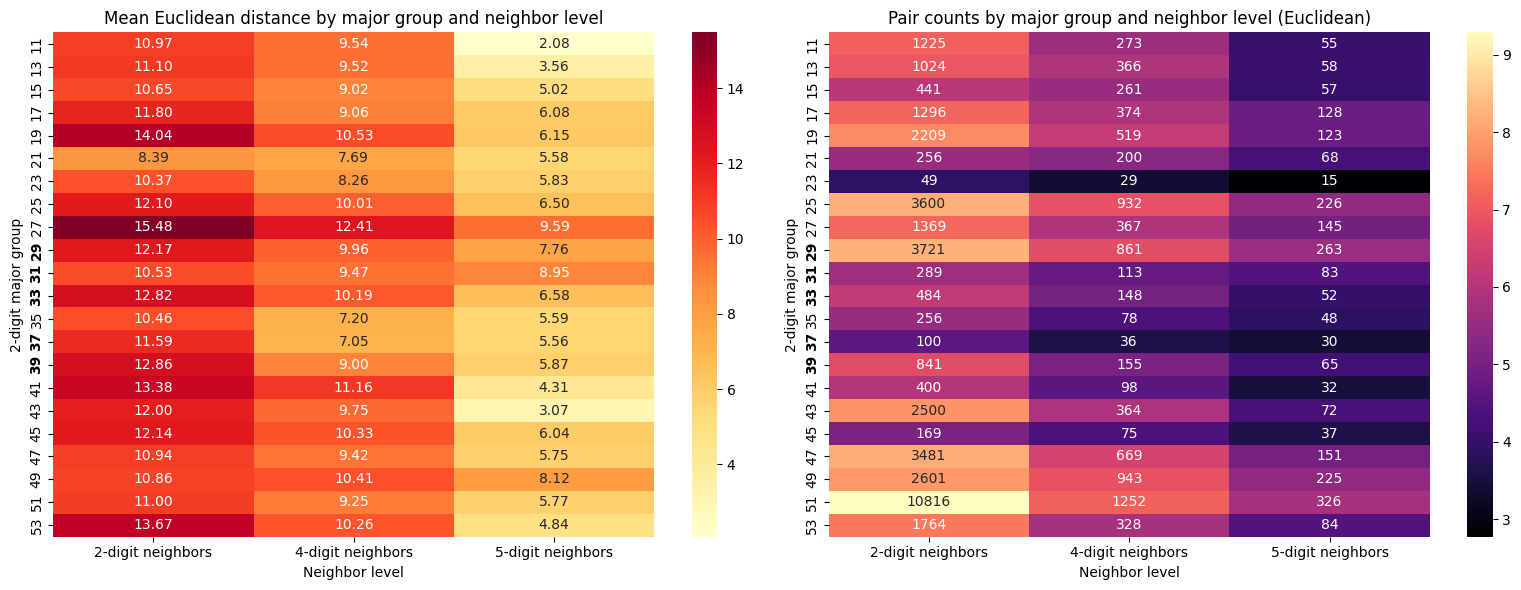

In [47]:
eu_neighbor_df = df_sim_metrics[["origin_soc", "destination_soc", "Euclid_distance_np_SKAWS_value"]].copy()
eu_neighbor_df["origin_norm"] = eu_neighbor_df["origin_soc"].apply(normalize_soc)
eu_neighbor_df["destination_norm"] = eu_neighbor_df["destination_soc"].apply(normalize_soc)
eu_neighbor_df = eu_neighbor_df.dropna(subset=["origin_norm", "destination_norm", "Euclid_distance_np_SKAWS_value"]).copy()

eu_neighbor_df["origin_digits"] = eu_neighbor_df["origin_norm"].str.replace("-", "", regex=False)
eu_neighbor_df["destination_digits"] = eu_neighbor_df["destination_norm"].str.replace("-", "", regex=False)
eu_neighbor_df = eu_neighbor_df[
    eu_neighbor_df["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & eu_neighbor_df["destination_digits"].str.fullmatch(r"\d{6}", na=False)
]

# Explicit prefix checks: same FIRST 2/4/5 digits.
eu_neighbor_df["same_2"] = eu_neighbor_df["origin_digits"].str.slice(0, 2).eq(
    eu_neighbor_df["destination_digits"].str.slice(0, 2)
)
eu_neighbor_df["same_4"] = eu_neighbor_df["origin_digits"].str.slice(0, 4).eq(
    eu_neighbor_df["destination_digits"].str.slice(0, 4)
)
eu_neighbor_df["same_5"] = eu_neighbor_df["origin_digits"].str.slice(0, 5).eq(
    eu_neighbor_df["destination_digits"].str.slice(0, 5)
)

# Sanity checks for hierarchical prefixes.
assert eu_neighbor_df.loc[eu_neighbor_df["same_5"], "same_4"].all()
assert eu_neighbor_df.loc[eu_neighbor_df["same_4"], "same_2"].all()

eu_level_specs = [
    ("2-digit neighbors", "same_2"),
    ("4-digit neighbors", "same_4"),
    ("5-digit neighbors", "same_5"),
]

eu_overall_rows = []
for level_name, level_col in eu_level_specs:
    vals = eu_neighbor_df.loc[eu_neighbor_df[level_col], "Euclid_distance_np_SKAWS_value"].dropna()
    eu_overall_rows.append({
        "level": level_name,
        "count": int(len(vals)),
        "mean_distance": float(vals.mean()) if len(vals) else np.nan,
        "median_distance": float(vals.median()) if len(vals) else np.nan,
        "p25": float(vals.quantile(0.25)) if len(vals) else np.nan,
        "p75": float(vals.quantile(0.75)) if len(vals) else np.nan,
    })

eu_overall_neighbor_summary = pd.DataFrame(eu_overall_rows)
print("Overall Euclidean neighbor summary (2/4/5-digit):")
display(eu_overall_neighbor_summary)

eu_within_2digit = eu_neighbor_df[eu_neighbor_df["same_2"]].copy()
eu_within_2digit["major_group"] = eu_within_2digit["origin_digits"].str[:2]

eu_nested_rows = []
for major_group, g in eu_within_2digit.groupby("major_group", sort=True):
    for level_name, level_col in eu_level_specs:
        vals = g.loc[g[level_col], "Euclid_distance_np_SKAWS_value"].dropna()
        eu_nested_rows.append({
            "major_group": major_group,
            "level": level_name,
            "count": int(len(vals)),
            "mean_distance": float(vals.mean()) if len(vals) else np.nan,
            "median_distance": float(vals.median()) if len(vals) else np.nan,
        })

eu_nested_neighbor_summary = pd.DataFrame(eu_nested_rows)

print("Nested Euclidean summary by 2-digit major group (first rows):")
display(eu_nested_neighbor_summary.sort_values(["major_group", "level"]).head(24))

eu_plot_df = eu_nested_neighbor_summary.pivot(
    index="major_group", columns="level", values="mean_distance"
).sort_index()

eu_count_df = eu_nested_neighbor_summary.pivot(
    index="major_group", columns="level", values="count"
).sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(eu_plot_df, cmap="YlOrRd", annot=True, fmt=".2f", ax=axes[0])
axes[0].set_title("Mean Euclidean distance by major group and neighbor level")
axes[0].set_xlabel("Neighbor level")
axes[0].set_ylabel("2-digit major group")

sns.heatmap(np.log1p(eu_count_df), cmap="magma", annot=eu_count_df, fmt=".0f", ax=axes[1])
axes[1].set_title("Pair counts by major group and neighbor level (Euclidean)")
axes[1].set_xlabel("Neighbor level")
axes[1].set_ylabel("2-digit major group")

highlight_codes = {"29", "33", "37", "31", "39"}
for ax in axes:
    for tick in ax.get_yticklabels():
        if tick.get_text() in highlight_codes:
            tick.set_fontweight("bold")

plt.tight_layout()
plt.show()

# Content Disagreement Metrics

In [48]:
# Concern tiers for disagreements using destination-within-occupation thresholds
base = disagree_df.copy()

skaw_col = "original_cosine_SKAWS_value"
euclid_col = "Euclid_distance_np_SKAWS_value"

# Destination occupation for each disagreement pair (already present in disagree_df from prior cell).
if "destination_occ" not in base.columns:
    base["destination_occ"] = base["human_soc"]

base = base.dropna(subset=[skaw_col, euclid_col, "destination_occ"]).copy()

# Build within-destination distributions from full df_sim_metrics.
within_dist = df_sim_metrics[["destination_soc", skaw_col, euclid_col]].copy()
within_dist["destination_norm"] = within_dist["destination_soc"].apply(normalize_soc)
within_dist = within_dist.dropna(subset=["destination_norm", skaw_col, euclid_col]).copy()

dest_thresholds = within_dist.groupby("destination_norm").agg(
    skaw_p99_within=(skaw_col, lambda s: s.quantile(0.99)),
    euclid_p01_within=(euclid_col, lambda s: s.quantile(0.01)),
    n_within=(skaw_col, "size"),
).reset_index()

base["destination_norm"] = base["destination_occ"].apply(normalize_soc)
base = base.merge(
    dest_thresholds,
    how="left",
    on="destination_norm",
)

base = base.dropna(subset=["skaw_p99_within", "euclid_p01_within"]).copy()

# Tier definitions from user (applied with precedence: high -> medium -> low).
high_flag = (base[skaw_col] < base["skaw_p99_within"]) & (base[euclid_col] > base["euclid_p01_within"])
medium_flag = ((base[skaw_col] < base["skaw_p99_within"]) | (base[euclid_col] > base["euclid_p01_within"])) & (~high_flag)

base["concern_level"] = np.select(
    [high_flag, medium_flag],
    ["high", "medium"],
    default="low",
)
base["concern_flag"] = base["concern_level"].isin(["high", "medium"])

# Persist per-tier DataFrames for direct inspection.
high_concern_df = base[base["concern_level"] == "high"].copy()
medium_concern_df = base[base["concern_level"] == "medium"].copy()
low_concern_df = base[base["concern_level"] == "low"].copy()

print("Within-occupation thresholds applied per destination occupation.")
print("High: SKAW < p99 AND Euclidean > p1")
print("Medium: (SKAW < p99 OR Euclidean > p1), excluding High")
print("Low: SKAW >= p99 AND Euclidean <= p1")
print(f"Rows with destination-specific thresholds available: {len(base)}")
print(
    f"Tier DataFrames ready -> high_concern_df: {len(high_concern_df)}, "
    f"medium_concern_df: {len(medium_concern_df)}, low_concern_df: {len(low_concern_df)}"
)

concern_summary = (
    base["concern_level"]
    .value_counts()
    .rename_axis("concern_level")
    .reset_index(name="count")
)
concern_summary["share"] = (concern_summary["count"] / concern_summary["count"].sum()).round(3)
display(concern_summary)

print("\nThreshold coverage by destination occupation (first 10):")
display(
    base[[
        "destination_occ",
        "n_within",
        "skaw_p99_within",
        "euclid_p01_within",
    ]]
    .drop_duplicates()
    .sort_values("destination_occ")
    .head(10)
)

# Verification: check rule consistency in each category.
verification = pd.DataFrame({
    "high_rows_match_rule": [int(((base["concern_level"] == "high") & ((base[skaw_col] < base["skaw_p99_within"]) & (base[euclid_col] > base["euclid_p01_within"]))).sum())],
    "medium_rows_match_rule": [int(((base["concern_level"] == "medium") & (((base[skaw_col] < base["skaw_p99_within"]) | (base[euclid_col] > base["euclid_p01_within"])) & ~((base[skaw_col] < base["skaw_p99_within"]) & (base[euclid_col] > base["euclid_p01_within"])))).sum())],
    "low_rows_match_rule": [int(((base["concern_level"] == "low") & ((base[skaw_col] >= base["skaw_p99_within"]) & (base[euclid_col] <= base["euclid_p01_within"]))).sum())],
    "high_total": [int((base["concern_level"] == "high").sum())],
    "medium_total": [int((base["concern_level"] == "medium").sum())],
    "low_total": [int((base["concern_level"] == "low").sum())],
})
print("\nVerification counts (rule-matching rows vs total rows in each concern level):")
display(verification)

for level in ["high", "medium", "low"]:
    sample = base[base["concern_level"] == level].head(20)
    print(f"\nManual verification sample - {level.upper()} (n={len(sample)} shown):")
    display(
        sample[[
            "ONET_2019",
            "human_soc",
            "destination_occ",
            skaw_col,
            euclid_col,
            "skaw_p99_within",
            "euclid_p01_within",
            "concern_level",
        ]]
    )

disagree_concern_df = base.copy()

Within-occupation thresholds applied per destination occupation.
High: SKAW < p99 AND Euclidean > p1
Medium: (SKAW < p99 OR Euclidean > p1), excluding High
Low: SKAW >= p99 AND Euclidean <= p1
Rows with destination-specific thresholds available: 382
Tier DataFrames ready -> high_concern_df: 306, medium_concern_df: 23, low_concern_df: 53


,concern_level,count,share
0,high,306,0.801
1,low,53,0.139
2,medium,23,0.060



Threshold coverage by destination occupation (first 10):


,destination_occ,n_within,skaw_p99_within,euclid_p01_within
27,11-1011,785,0.981117,11.510326
29,11-1021,785,0.981374,7.372026
10,11-2011,785,0.974659,9.544702
259,11-2021,785,0.977947,8.772664
24,11-2022,785,0.982319,8.199421
91,11-3013,785,0.981506,8.058745
140,11-3031,785,0.979516,8.829315
92,11-3051,785,0.972770,10.137375
40,11-9021,785,0.975018,10.550444
130,11-9033,785,0.983163,7.911380



Verification counts (rule-matching rows vs total rows in each concern level):


...

,ONET_2019,human_soc,destination_occ,original_cosine_SKAWS_value,Euclid_distance_np_SKAWS_value,skaw_p99_within,euclid_p01_within,concern_level
0,11-9111,21-1013,21-1013,0.920778,17.136125,0.975661,8.634337,high
1,11-9111,21-1019,21-1019,0.956836,13.065796,0.988227,6.083966,high
2,11-2021,13-2054,13-2054,0.973454,10.330256,0.982724,7.492838,high
3,11-2021,13-1161,13-1161,0.979223,8.783747,0.979614,8.460236,high
4,11-2021,15-2031,15-2031,0.954574,12.791454,0.970544,9.711742,high
5,11-2021,15-2051,15-2051,0.964180,11.432559,0.978491,8.200921,high
6,11-9111,29-2099,29-2099,0.956199,14.398972,0.982848,7.440116,high
7,11-2021,19-1021,19-1021,0.896084,19.861648,0.975048,11.237419,high
8,11-2021,11-9121,11-9121,0.944172,13.272545,0.973130,10.351388,high
9,11-2021,17-2031,17-2031,0.908551,18.258011,0.976884,10.942683,high



Manual verification sample - MEDIUM (n=20 shown):


,ONET_2019,human_soc,destination_occ,original_cosine_SKAWS_value,Euclid_distance_np_SKAWS_value,skaw_p99_within,euclid_p01_within,concern_level
31,11-9041,17-3011,17-3011,0.976555,13.034657,0.970900,9.948051,medium
69,15-1252,15-2051,15-2051,0.977829,8.011462,0.978491,8.200921,medium
81,17-3011,17-1011,17-1011,0.977226,13.649673,0.973079,10.574939,medium
94,17-2112,17-2141,17-2141,0.972401,10.166577,0.974577,10.217207,medium
98,19-1022,19-4021,19-4021,0.972069,12.947232,0.957914,11.253844,medium
108,19-1023,19-2041,19-2041,0.975430,9.083187,0.975580,9.155038,medium
152,25-2031,25-3021,25-3021,0.971047,11.528153,0.967886,9.579729,medium
161,25-3021,25-2011,25-2011,0.966583,8.684241,0.968411,9.400274,medium
193,27-3041,43-9081,43-9081,0.929361,19.575222,0.925181,12.774689,medium
217,35-2014,35-2021,35-2021,0.976178,9.482767,0.968803,8.257035,medium



Manual verification sample - LOW (n=20 shown):


,ONET_2019,human_soc,destination_occ,original_cosine_SKAWS_value,Euclid_distance_np_SKAWS_value,skaw_p99_within,euclid_p01_within,concern_level
10,11-2021,11-2011,11-2011,0.989804,5.955637,0.974659,9.544702,low
25,11-9199,13-1082,13-1082,0.983440,7.258132,0.982499,8.251004,low
32,11-9041,17-2051,17-2051,0.982535,8.173422,0.974099,9.809344,low
38,13-2051,13-2011,13-2011,0.983645,6.822597,0.981760,7.680693,low
39,13-2051,13-2031,13-2031,0.973622,8.330770,0.973622,8.910698,low
41,13-2099,15-2031,15-2031,0.977066,8.483947,0.970544,9.711742,low
42,13-2099,15-2051,15-2051,0.983682,7.409948,0.978491,8.200921,low
48,13-2052,41-3031,41-3031,0.983210,7.580262,0.981286,8.219686,low
49,13-1082,13-1111,13-1111,0.984212,8.009859,0.982447,8.333287,low
51,13-2051,13-2011,13-2011,0.983645,6.822597,0.981760,7.680693,low


# Indexing off the Agreement DataFrame 

Agreement pair rows with both metrics: 477
Disagreement pair rows with both metrics: 382

Baseline profile from completely_agree_df:


,metric,mu,sigma
0,Euclid_distance_np_SKAWS_value,1.060133,3.122606
1,original_cosine_SKAWS_value,0.996437,0.011908



Thresholds used:
Strict cutoff (Euclid <= mu + 1sigma): 4.1827
Moderate cutoff (Euclid <= mu + 2sigma): 7.3053
Baseline Euclid 99th percentile: 12.9170

Filtered disagreement summary:


,group,count,avg_skaw_similarity,MAE_euclid,MSE_euclid,MAE_skaw,MSE_skaw
0,strict_disagreement,0,NaN,NaN,NaN,NaN,NaN
1,moderate_disagreement,27,0.983801,5.700167,32.745403,0.012636,0.000184
2,high_concern_outliers,355,0.949879,11.298248,140.356028,0.046558,0.002966


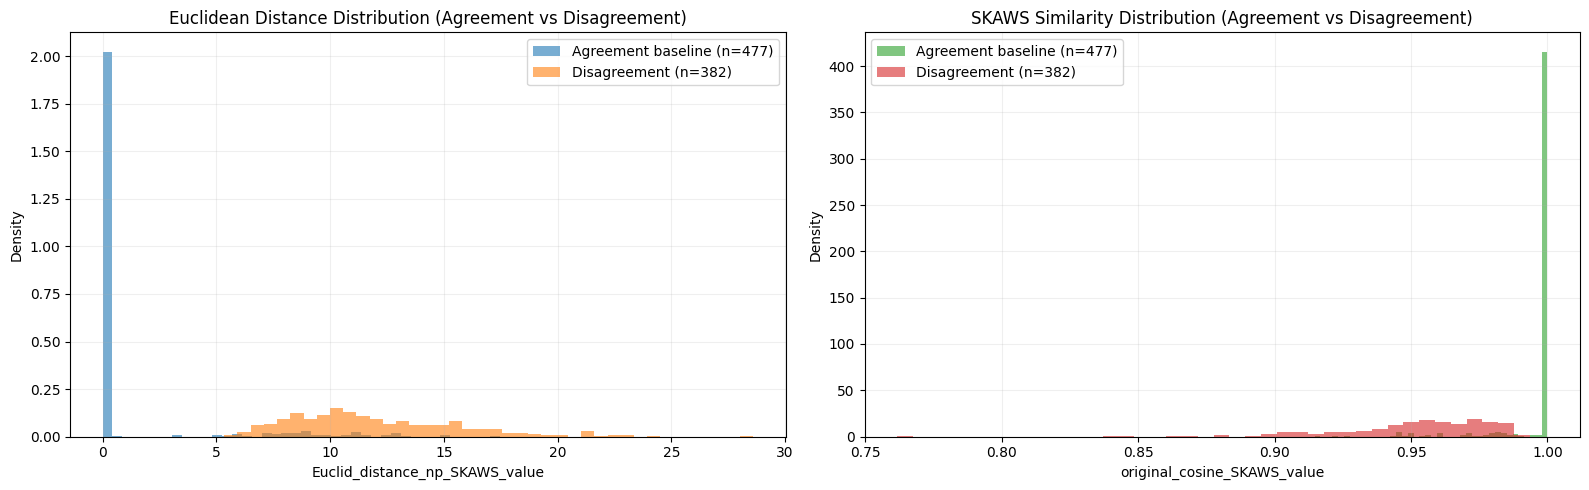


High concern preview (with Human SOC, LightCast SOC, and z-score):


,ONET_2019,lightcast_soc_norm,human_soc_norm,Euclid_distance_np_SKAWS_value,original_cosine_SKAWS_value,z_euclid_vs_agree
0,11-9111,11-9111,21-1013,17.136125,0.920778,5.148262
2,11-9111,11-9111,21-1019,13.065796,0.956836,3.844758
3,11-2021,11-2021,13-2054,10.330256,0.973454,2.968714
4,11-2021,11-2021,13-1161,8.783747,0.979223,2.473452
5,11-2021,11-2021,15-2031,12.791454,0.954574,3.756901
6,11-2021,11-2021,15-2051,11.432559,0.964180,3.321721
7,11-9111,11-9111,29-2099,14.398972,0.956199,4.271701
8,11-2021,11-2021,19-1021,19.861648,0.896084,6.021098
9,11-2021,11-2021,11-9121,13.272545,0.944172,3.910968
10,11-2021,11-2021,17-2031,18.258011,0.908551,5.507541


In [49]:

# Baseline-indexed disagreement filtering using Complete Agree as gold standard
# Inputs expected in kernel:
# - df_sim_metrics
# - completely_agree_df
# - completely_disagree_df
# - helper functions: normalize_soc, extract_human_soc_list

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SKAW_COL = "original_cosine_SKAWS_value"
EUCLID_COL = "Euclid_distance_np_SKAWS_value"


def build_pair_metrics(verdict_df, label):
    """Create pair-level metric table by exploding human SOC choices and joining both metric directions."""
    work = verdict_df.copy()
    work["ONET_2019_norm"] = work["ONET_2019"].apply(normalize_soc)
    work["human_soc_list"] = work["Human options 6-digit"].apply(extract_human_soc_list)

    pairs = (
        work
        .explode("human_soc_list")
        .rename(columns={"human_soc_list": "human_soc"})
    )
    pairs = pairs[pairs["ONET_2019_norm"].notna() & pairs["human_soc"].notna()].copy().reset_index(drop=True)

    sim = df_sim_metrics[["origin_soc", "destination_soc", SKAW_COL, EUCLID_COL]].copy()
    sim["origin_soc_norm"] = sim["origin_soc"].apply(normalize_soc)
    sim["destination_soc_norm"] = sim["destination_soc"].apply(normalize_soc)
    sim = sim.dropna(subset=["origin_soc_norm", "destination_soc_norm"]).copy()

    m1 = pairs.merge(
        sim,
        left_on=["ONET_2019_norm", "human_soc"],
        right_on=["origin_soc_norm", "destination_soc_norm"],
        how="left",
    ).rename(columns={SKAW_COL: "skaw_A", EUCLID_COL: "euclid_A"})

    m2 = pairs.merge(
        sim,
        left_on=["ONET_2019_norm", "human_soc"],
        right_on=["destination_soc_norm", "origin_soc_norm"],
        how="left",
    ).rename(columns={SKAW_COL: "skaw_B", EUCLID_COL: "euclid_B"})

    m1 = m1.reset_index(drop=True)
    m2 = m2.reset_index(drop=True)

    out = pairs[["ONET_2019", "ONET_2019_norm", "human_soc"]].copy().reset_index(drop=True)
    out[SKAW_COL] = m1["skaw_A"].combine_first(m2["skaw_B"])
    out[EUCLID_COL] = m1["euclid_A"].combine_first(m2["euclid_B"])
    out["group"] = label
    return out


# 1) Build pair-level metric frames for baseline and disagreement sets
metrics_agree = build_pair_metrics(completely_agree_df, "agreement")
metrics_disagree = build_pair_metrics(completely_disagree_df, "disagreement")

metrics_agree = metrics_agree.dropna(subset=[SKAW_COL, EUCLID_COL]).copy()
metrics_disagree = metrics_disagree.dropna(subset=[SKAW_COL, EUCLID_COL]).copy()

print(f"Agreement pair rows with both metrics: {len(metrics_agree)}")
print(f"Disagreement pair rows with both metrics: {len(metrics_disagree)}")

# 2) Baseline stats from Complete Agree profile
mu_euclid = metrics_agree[EUCLID_COL].mean()
sigma_euclid = metrics_agree[EUCLID_COL].std(ddof=0)
mu_skaw = metrics_agree[SKAW_COL].mean()
sigma_skaw = metrics_agree[SKAW_COL].std(ddof=0)
p99_euclid_baseline = metrics_agree[EUCLID_COL].quantile(0.99)

euclid_strict_cutoff = mu_euclid + (1.0 * sigma_euclid)
euclid_moderate_cutoff = mu_euclid + (2.0 * sigma_euclid)

# 3) Add z-scores for inspection
if sigma_euclid == 0 or np.isnan(sigma_euclid):
    metrics_disagree["z_euclid_vs_agree"] = np.nan
else:
    metrics_disagree["z_euclid_vs_agree"] = (metrics_disagree[EUCLID_COL] - mu_euclid) / sigma_euclid

# 4) Requested filtered disagreement dataframes
# Strict: close-cousin disagreements only (<= mu + 1 sigma)
df_strict_disagreement = metrics_disagree[
    metrics_disagree[EUCLID_COL] <= euclid_strict_cutoff
].copy()

# Moderate: broader acceptable disagreements (<= mu + 2 sigma)
df_moderate_disagreement = metrics_disagree[
    metrics_disagree[EUCLID_COL] <= euclid_moderate_cutoff
].copy()

# High concern: > mu + 2 sigma OR above baseline 99th percentile
high_concern_mask = (
    (metrics_disagree[EUCLID_COL] > euclid_moderate_cutoff)
    | (metrics_disagree[EUCLID_COL] > p99_euclid_baseline)
)
df_high_concern_outliers = metrics_disagree.loc[
    high_concern_mask,
    ["ONET_2019", "ONET_2019_norm", "human_soc", EUCLID_COL, SKAW_COL, "z_euclid_vs_agree"],
].copy()

# Friendly alias for explicit LightCast SOC naming
df_high_concern_outliers = df_high_concern_outliers.rename(
    columns={"ONET_2019_norm": "lightcast_soc_norm", "human_soc": "human_soc_norm"}
)

# 5) MAE/MSE vs agreement means for each new dataframe

def calc_error_metrics(df_in):
    if len(df_in) == 0:
        return {
            "MAE_euclid": np.nan,
            "MSE_euclid": np.nan,
            "MAE_skaw": np.nan,
            "MSE_skaw": np.nan,
        }

    err_euclid = df_in[EUCLID_COL] - mu_euclid
    err_skaw = df_in[SKAW_COL] - mu_skaw
    return {
        "MAE_euclid": float(err_euclid.abs().mean()),
        "MSE_euclid": float((err_euclid ** 2).mean()),
        "MAE_skaw": float(err_skaw.abs().mean()),
        "MSE_skaw": float((err_skaw ** 2).mean()),
    }

strict_err = calc_error_metrics(df_strict_disagreement)
moderate_err = calc_error_metrics(df_moderate_disagreement)
outlier_err = calc_error_metrics(df_high_concern_outliers)

# 6) Summary table: counts + avg SKAW + MAE/MSE
summary_table = pd.DataFrame([
    {
        "group": "strict_disagreement",
        "count": int(len(df_strict_disagreement)),
        "avg_skaw_similarity": float(df_strict_disagreement[SKAW_COL].mean()) if len(df_strict_disagreement) else np.nan,
        **strict_err,
    },
    {
        "group": "moderate_disagreement",
        "count": int(len(df_moderate_disagreement)),
        "avg_skaw_similarity": float(df_moderate_disagreement[SKAW_COL].mean()) if len(df_moderate_disagreement) else np.nan,
        **moderate_err,
    },
    {
        "group": "high_concern_outliers",
        "count": int(len(df_high_concern_outliers)),
        "avg_skaw_similarity": float(df_high_concern_outliers[SKAW_COL].mean()) if len(df_high_concern_outliers) else np.nan,
        **outlier_err,
    },
])

# 7) Print baseline profile + thresholds + summary
baseline_profile = pd.DataFrame({
    "metric": [EUCLID_COL, SKAW_COL],
    "mu": [mu_euclid, mu_skaw],
    "sigma": [sigma_euclid, sigma_skaw],
})

print("\nBaseline profile from completely_agree_df:")
display(baseline_profile)

print("\nThresholds used:")
print(f"Strict cutoff (Euclid <= mu + 1sigma): {euclid_strict_cutoff:.4f}")
print(f"Moderate cutoff (Euclid <= mu + 2sigma): {euclid_moderate_cutoff:.4f}")
print(f"Baseline Euclid 99th percentile: {p99_euclid_baseline:.4f}")

print("\nFiltered disagreement summary:")
display(summary_table)

# 8) Unsmoothed histograms (Agreement vs Disagreement)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Euclidean distance histogram
axes[0].hist(
    metrics_agree[EUCLID_COL],
    bins=40,
    density=True,
    alpha=0.6,
    color="#1f77b4",
    label=f"Agreement baseline (n={len(metrics_agree):,})",
)
axes[0].hist(
    metrics_disagree[EUCLID_COL],
    bins=40,
    density=True,
    alpha=0.6,
    color="#ff7f0e",
    label=f"Disagreement (n={len(metrics_disagree):,})",
)
axes[0].set_title("Euclidean Distance Distribution (Agreement vs Disagreement)")
axes[0].set_xlabel(EUCLID_COL)
axes[0].set_ylabel("Density")
axes[0].grid(alpha=0.2)
axes[0].legend()

# SKAWS similarity histogram
axes[1].hist(
    metrics_agree[SKAW_COL],
    bins=40,
    density=True,
    alpha=0.6,
    color="#2ca02c",
    label=f"Agreement baseline (n={len(metrics_agree):,})",
)
axes[1].hist(
    metrics_disagree[SKAW_COL],
    bins=40,
    density=True,
    alpha=0.6,
    color="#d62728",
    label=f"Disagreement (n={len(metrics_disagree):,})",
)
axes[1].set_title("SKAWS Similarity Distribution (Agreement vs Disagreement)")
axes[1].set_xlabel(SKAW_COL)
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nHigh concern preview (with Human SOC, LightCast SOC, and z-score):")
display(df_high_concern_outliers.head(20))


Rows used for modeling: 616,225
AUC summary (higher is better; 0.5 = random):


,target,positive_rate,AUC_SKAW_only,AUC_Euclid_only,AUC_Combined_OOF
0,4-digit match,0.013698,0.902770,0.902557,0.909749
1,5-digit match,0.003802,0.949174,0.948581,0.952733


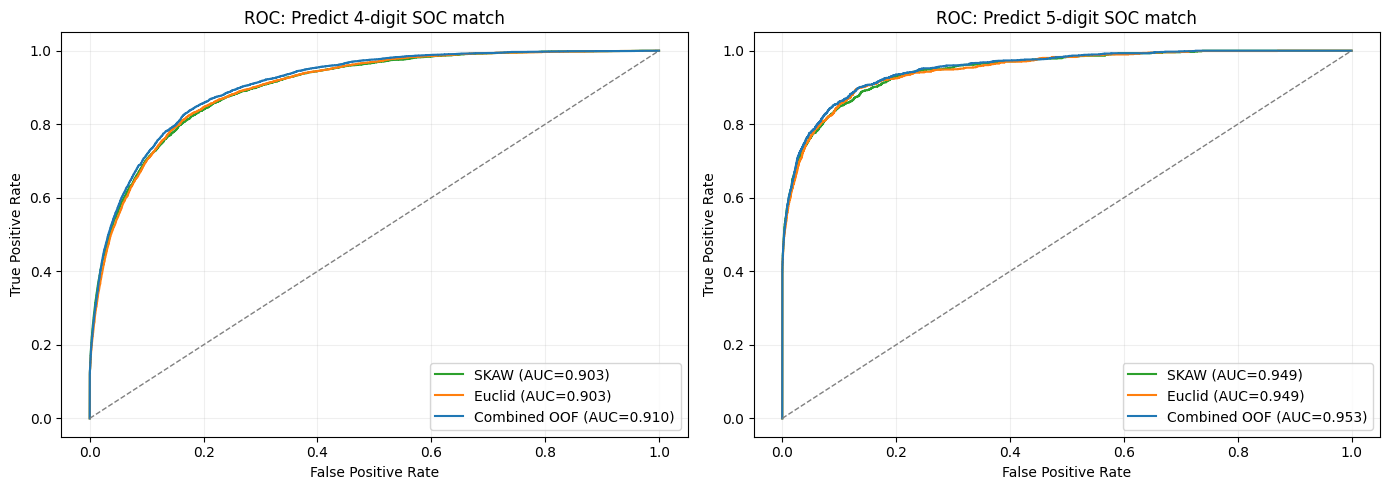

In [51]:
# Predicting SOC prefix matches from SKAW similarity and Euclidean distance
# Outputs AUC for 4-digit and 5-digit match classification.

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_df = df_sim_metrics[["origin_soc", "destination_soc", "original_cosine_SKAWS_value", "Euclid_distance_np_SKAWS_value"]].copy()
model_df = model_df.rename(
    columns={
        "original_cosine_SKAWS_value": "skaw",
        "Euclid_distance_np_SKAWS_value": "euclid",
    }
)

model_df["origin_norm"] = model_df["origin_soc"].apply(normalize_soc)
model_df["destination_norm"] = model_df["destination_soc"].apply(normalize_soc)

model_df = model_df.dropna(subset=["origin_norm", "destination_norm", "skaw", "euclid"]).copy()
model_df["origin_digits"] = model_df["origin_norm"].str.replace("-", "", regex=False)
model_df["destination_digits"] = model_df["destination_norm"].str.replace("-", "", regex=False)

model_df = model_df[
    model_df["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & model_df["destination_digits"].str.fullmatch(r"\d{6}", na=False)
].copy()

model_df["match_4digit"] = (
    model_df["origin_digits"].str.slice(0, 4) == model_df["destination_digits"].str.slice(0, 4)
).astype(int)
model_df["match_5digit"] = (
    model_df["origin_digits"].str.slice(0, 5) == model_df["destination_digits"].str.slice(0, 5)
).astype(int)

X = model_df[["skaw", "euclid"]]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]
)


def compute_auc_bundle(y):
    # Single-feature AUCs
    auc_skaw = roc_auc_score(y, model_df["skaw"])
    auc_euclid = roc_auc_score(y, -model_df["euclid"])  # lower Euclidean => more likely match

    # Combined-feature out-of-fold AUC
    oof_proba = cross_val_predict(pipe, X, y, cv=skf, method="predict_proba")[:, 1]
    auc_combined = roc_auc_score(y, oof_proba)

    fpr_skaw, tpr_skaw, _ = roc_curve(y, model_df["skaw"])
    fpr_euc, tpr_euc, _ = roc_curve(y, -model_df["euclid"])
    fpr_combo, tpr_combo, _ = roc_curve(y, oof_proba)

    return {
        "auc_skaw": auc_skaw,
        "auc_euclid": auc_euclid,
        "auc_combined": auc_combined,
        "fpr_skaw": fpr_skaw,
        "tpr_skaw": tpr_skaw,
        "fpr_euc": fpr_euc,
        "tpr_euc": tpr_euc,
        "fpr_combo": fpr_combo,
        "tpr_combo": tpr_combo,
    }


res_4 = compute_auc_bundle(model_df["match_4digit"])
res_5 = compute_auc_bundle(model_df["match_5digit"])

auc_summary = pd.DataFrame(
    [
        {
            "target": "4-digit match",
            "positive_rate": model_df["match_4digit"].mean(),
            "AUC_SKAW_only": res_4["auc_skaw"],
            "AUC_Euclid_only": res_4["auc_euclid"],
            "AUC_Combined_OOF": res_4["auc_combined"],
        },
        {
            "target": "5-digit match",
            "positive_rate": model_df["match_5digit"].mean(),
            "AUC_SKAW_only": res_5["auc_skaw"],
            "AUC_Euclid_only": res_5["auc_euclid"],
            "AUC_Combined_OOF": res_5["auc_combined"],
        },
    ]
)

print(f"Rows used for modeling: {len(model_df):,}")
print("AUC summary (higher is better; 0.5 = random):")
display(auc_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(res_4["fpr_skaw"], res_4["tpr_skaw"], label=f"SKAW (AUC={res_4['auc_skaw']:.3f})", color="#2ca02c")
axes[0].plot(res_4["fpr_euc"], res_4["tpr_euc"], label=f"Euclid (AUC={res_4['auc_euclid']:.3f})", color="#ff7f0e")
axes[0].plot(res_4["fpr_combo"], res_4["tpr_combo"], label=f"Combined OOF (AUC={res_4['auc_combined']:.3f})", color="#1f77b4")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC: Predict 4-digit SOC match")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(res_5["fpr_skaw"], res_5["tpr_skaw"], label=f"SKAW (AUC={res_5['auc_skaw']:.3f})", color="#2ca02c")
axes[1].plot(res_5["fpr_euc"], res_5["tpr_euc"], label=f"Euclid (AUC={res_5['auc_euclid']:.3f})", color="#ff7f0e")
axes[1].plot(res_5["fpr_combo"], res_5["tpr_combo"], label=f"Combined OOF (AUC={res_5['auc_combined']:.3f})", color="#1f77b4")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[1].set_title("ROC: Predict 5-digit SOC match")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


Differentiation summary for 5-digit vs 2-digit-only:


,comparison,n_rows,positive_rate_5digit,AUC_SKAW,AUC_Euclid,best_threshold_SKAW,best_threshold_negEuclid
0,5-digit vs 2-digit-only,38891,0.060245,0.811187,0.814526,0.972925,-8.601707


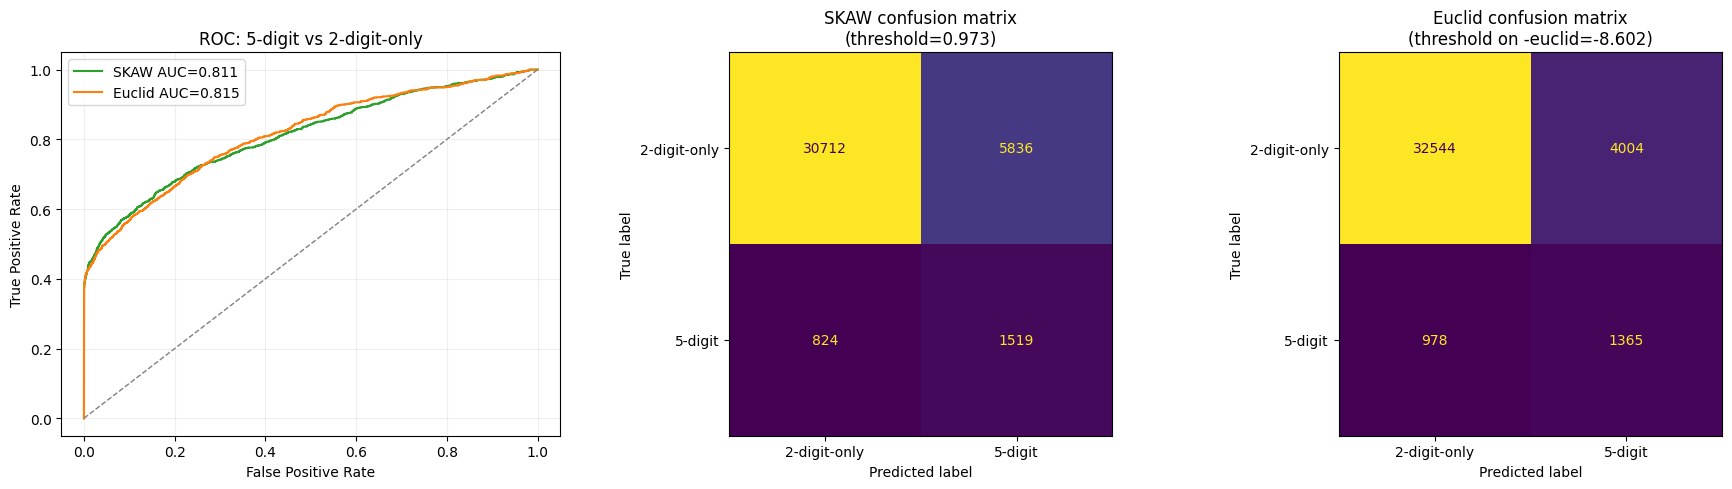

In [52]:
# Two-group differentiation: 2-digit-only vs 5-digit SOC matches
# Goal: compare Euclidean vs cosine (SKAW) using AUC and confusion matrices.

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

cmp_df = df_sim_metrics[["origin_soc", "destination_soc", "original_cosine_SKAWS_value", "Euclid_distance_np_SKAWS_value"]].copy()
cmp_df["origin_norm"] = cmp_df["origin_soc"].apply(normalize_soc)
cmp_df["destination_norm"] = cmp_df["destination_soc"].apply(normalize_soc)
cmp_df = cmp_df.dropna(subset=["origin_norm", "destination_norm", "original_cosine_SKAWS_value", "Euclid_distance_np_SKAWS_value"]).copy()

cmp_df["origin_digits"] = cmp_df["origin_norm"].str.replace("-", "", regex=False)
cmp_df["destination_digits"] = cmp_df["destination_norm"].str.replace("-", "", regex=False)
cmp_df = cmp_df[
    cmp_df["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & cmp_df["destination_digits"].str.fullmatch(r"\d{6}", na=False)
].copy()

cmp_df["same_2"] = cmp_df["origin_digits"].str[:2] == cmp_df["destination_digits"].str[:2]
cmp_df["same_5"] = cmp_df["origin_digits"].str[:5] == cmp_df["destination_digits"].str[:5]

# Build non-overlapping groups:
# - negative class (0): 2-digit-only (same_2 and not same_5)
# - positive class (1): 5-digit match
cmp_df = cmp_df[(cmp_df["same_5"]) | (cmp_df["same_2"] & ~cmp_df["same_5"])].copy()
cmp_df["y_5_vs_2only"] = cmp_df["same_5"].astype(int)

y = cmp_df["y_5_vs_2only"]
score_skaw = cmp_df["original_cosine_SKAWS_value"]
score_euclid = -cmp_df["Euclid_distance_np_SKAWS_value"]  # invert so higher means more likely 5-digit match

def best_threshold_by_youden(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    j = tpr - fpr
    idx = int(np.argmax(j))
    return float(thresholds[idx]), fpr, tpr

auc_skaw = roc_auc_score(y, score_skaw)
auc_euclid = roc_auc_score(y, score_euclid)

thr_skaw, fpr_skaw, tpr_skaw = best_threshold_by_youden(y, score_skaw)
thr_euclid, fpr_euclid, tpr_euclid = best_threshold_by_youden(y, score_euclid)

pred_skaw = (score_skaw >= thr_skaw).astype(int)
pred_euclid = (score_euclid >= thr_euclid).astype(int)

cm_skaw = confusion_matrix(y, pred_skaw)
cm_euclid = confusion_matrix(y, pred_euclid)

summary = pd.DataFrame([
    {
        "comparison": "5-digit vs 2-digit-only",
        "n_rows": int(len(cmp_df)),
        "positive_rate_5digit": float(y.mean()),
        "AUC_SKAW": float(auc_skaw),
        "AUC_Euclid": float(auc_euclid),
        "best_threshold_SKAW": float(thr_skaw),
        "best_threshold_negEuclid": float(thr_euclid),
    }
])

print("Differentiation summary for 5-digit vs 2-digit-only:")
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(fpr_skaw, tpr_skaw, color="#2ca02c", label=f"SKAW AUC={auc_skaw:.3f}")
axes[0].plot(fpr_euclid, tpr_euclid, color="#ff7f0e", label=f"Euclid AUC={auc_euclid:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC: 5-digit vs 2-digit-only")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.2)

ConfusionMatrixDisplay(cm_skaw, display_labels=["2-digit-only", "5-digit"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title(f"SKAW confusion matrix\n(threshold={thr_skaw:.3f})")

ConfusionMatrixDisplay(cm_euclid, display_labels=["2-digit-only", "5-digit"]).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f"Euclid confusion matrix\n(threshold on -euclid={thr_euclid:.3f})")

plt.tight_layout()
plt.show()


# Disagreement Metrics by Mean Transitions Values

Literature-threshold disagreement summary (SKAWS mean similarity):


,literature_disagreement_level,count,mean_similarity,min_similarity,max_similarity,share
0,low_disagreement (>=0.96),171,0.974364,0.960377,0.993581,0.447644
1,medium_disagreement (0.94-0.96),120,0.951153,0.940100,0.959998,0.314136
2,high_disagreement (0.92-0.94),43,0.931530,0.920472,0.939946,0.112565
3,very_high_disagreement (<0.92),48,0.894989,0.761636,0.919621,0.125654


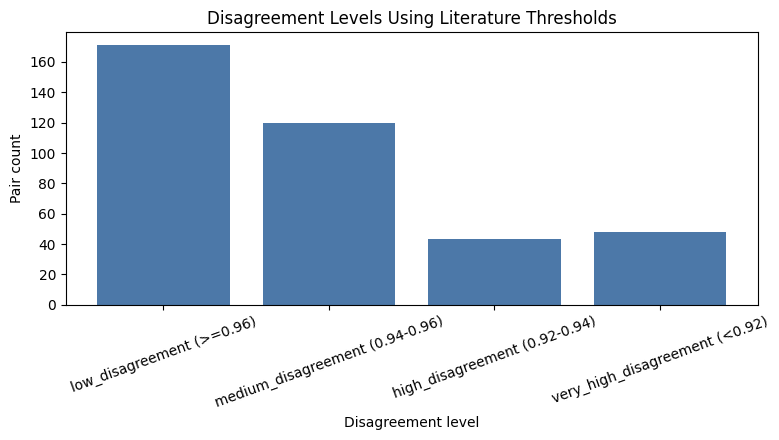

In [57]:
# Literature-based disagreement levels using mean SKAWS similarity thresholds
# Requested mapping: concern levels (re--Stansbury paper)
# Low: >=0.96, Medium: [0.94, 0.96), High: [0.92, 0.94), Very high: <0.92

lit_thresholds = [0.92, 0.94, 0.96]

if "metrics_disagree" not in globals():
    raise NameError("metrics_disagree is not defined. Run the disagreement metrics cells above first.")

if SKAW_COL not in metrics_disagree.columns:
    raise KeyError(f"{SKAW_COL} is missing from metrics_disagree columns.")

literature_disagreement_df = metrics_disagree.copy()
literature_disagreement_df = literature_disagreement_df.dropna(subset=[SKAW_COL]).copy()

conditions = [
    literature_disagreement_df[SKAW_COL] >= lit_thresholds[2],
    (literature_disagreement_df[SKAW_COL] >= lit_thresholds[1]) & (literature_disagreement_df[SKAW_COL] < lit_thresholds[2]),
    (literature_disagreement_df[SKAW_COL] >= lit_thresholds[0]) & (literature_disagreement_df[SKAW_COL] < lit_thresholds[1]),
    literature_disagreement_df[SKAW_COL] < lit_thresholds[0],
]

labels = [
    "low_disagreement (>=0.96)",
    "medium_disagreement (0.94-0.96)",
    "high_disagreement (0.92-0.94)",
    "very_high_disagreement (<0.92)",
]

literature_disagreement_df["literature_disagreement_level"] = np.select(
    conditions,
    labels,
    default="unclassified",
)

level_order = [
    "low_disagreement (>=0.96)",
    "medium_disagreement (0.94-0.96)",
    "high_disagreement (0.92-0.94)",
    "very_high_disagreement (<0.92)",
]

literature_summary = (
    literature_disagreement_df
    .groupby("literature_disagreement_level", dropna=False)
    .agg(
        count=(SKAW_COL, "size"),
        mean_similarity=(SKAW_COL, "mean"),
        min_similarity=(SKAW_COL, "min"),
        max_similarity=(SKAW_COL, "max"),
    )
    .reindex(level_order)
    .reset_index()
)

literature_summary["share"] = literature_summary["count"] / literature_summary["count"].sum()

print("Literature-threshold disagreement summary (SKAWS mean similarity):")
display(literature_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = literature_summary.dropna(subset=["count"]).copy()
ax.bar(plot_data["literature_disagreement_level"], plot_data["count"], color="#4C78A8")
ax.set_title("Disagreement Levels Using Literature Thresholds")
ax.set_xlabel("Disagreement level")
ax.set_ylabel("Pair count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


# Disagreement by Comparing to 2, 4, 5 digit similarities

,group,count,mean_similarity,median_similarity,p10,p25,p75,p90
0,Exactly 2 leading digits match,26860,0.946460,0.953472,0.910821,0.934644,0.966246,0.974045
1,Exactly 4 leading digits match,6098,0.957371,0.962821,0.927465,0.947447,0.973588,0.980106
2,Exactly 5 leading digits match,1558,0.966819,0.971511,0.941874,0.957168,0.981572,0.988584
3,Disagreement metrics,382,0.952277,0.957766,0.912337,0.941315,0.972378,0.981946


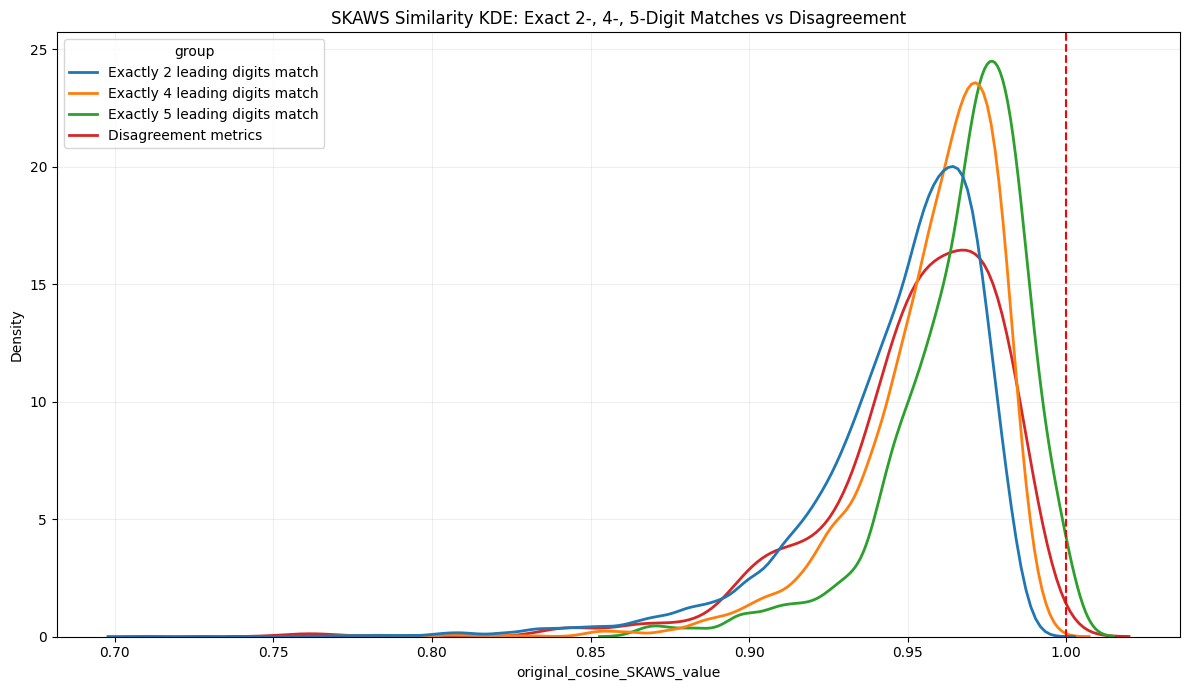

In [68]:
if "metrics_disagree" not in globals():
    raise NameError("metrics_disagree is not defined. Run the disagreement metrics cells above first.")

sim_dist = df_sim_metrics[["origin_soc", "destination_soc", SKAW_COL]].copy()
sim_dist["origin_norm"] = sim_dist["origin_soc"].apply(normalize_soc)
sim_dist["destination_norm"] = sim_dist["destination_soc"].apply(normalize_soc)
sim_dist = sim_dist.dropna(subset=["origin_norm", "destination_norm", SKAW_COL]).copy()

sim_dist["origin_digits"] = sim_dist["origin_norm"].str.replace("-", "", regex=False)
sim_dist["destination_digits"] = sim_dist["destination_norm"].str.replace("-", "", regex=False)

sim_dist = sim_dist[
    sim_dist["origin_digits"].str.fullmatch(r"\d{6}", na=False)
    & sim_dist["destination_digits"].str.fullmatch(r"\d{6}", na=False)
].copy()

same_1 = sim_dist["origin_digits"].str[:1] == sim_dist["destination_digits"].str[:1]
same_2 = sim_dist["origin_digits"].str[:2] == sim_dist["destination_digits"].str[:2]
same_3 = sim_dist["origin_digits"].str[:3] == sim_dist["destination_digits"].str[:3]
same_4 = sim_dist["origin_digits"].str[:4] == sim_dist["destination_digits"].str[:4]
same_5 = sim_dist["origin_digits"].str[:5] == sim_dist["destination_digits"].str[:5]
same_6 = sim_dist["origin_digits"] == sim_dist["destination_digits"]

exact_2 = same_2 & ~same_3
exact_4 = same_4 & ~same_5
exact_5 = same_5 & ~same_6

disagree_vals = metrics_disagree[SKAW_COL].dropna()

distribution_specs = [
    ("Exactly 2 leading digits match", sim_dist.loc[exact_2, SKAW_COL].dropna()),
    ("Exactly 4 leading digits match", sim_dist.loc[exact_4, SKAW_COL].dropna()),
    ("Exactly 5 leading digits match", sim_dist.loc[exact_5, SKAW_COL].dropna()),
    ("Disagreement metrics", disagree_vals),
]

summary_rows = []
for label, vals in distribution_specs:
    summary_rows.append({
        "group": label,
        "count": int(len(vals)),
        "mean_similarity": float(vals.mean()) if len(vals) else np.nan,
        "median_similarity": float(vals.median()) if len(vals) else np.nan,
        "p10": float(vals.quantile(0.10)) if len(vals) else np.nan,
        "p25": float(vals.quantile(0.25)) if len(vals) else np.nan,
        "p75": float(vals.quantile(0.75)) if len(vals) else np.nan,
        "p90": float(vals.quantile(0.90)) if len(vals) else np.nan,
    })

comparison_summary = pd.DataFrame(summary_rows)
display(comparison_summary)

plot_df = pd.concat(
    [
        pd.DataFrame({"group": label, SKAW_COL: vals})
        for label, vals in distribution_specs
        if len(vals)
    ],
    ignore_index=True,
)

plt.figure(figsize=(12, 7))
sns.kdeplot(
    data=plot_df,
    x=SKAW_COL,
    hue="group",
    common_norm=False,
    fill=False,
    linewidth=2,
)

plt.title("SKAWS Similarity KDE: Exact 2-, 4-, 5-Digit Matches vs Disagreement")
plt.xlabel(SKAW_COL)
plt.ylabel("Density")
plt.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="x = 1.0")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
